# Overview (Donor)

The second phase of data wrangling focused on donor variables and recipient sex stratification. Exploratory visualizations were used to assess feature distributions, identify data quality issues, and support data cleaning. Shadow variables were created to track missingness across features and facilitate examination of missing-data patterns. This process improved understanding of feature behavior and data completeness, informing subsequent informative-missingness testing, imputation, and modeling decisions.

In [38]:
# path to user functions
import sys  
sys.path.append('../modules/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys

# set seaborn theme
sns.set_theme()

# python modules
import collinearity_check as cc
import heart_utilities as u
import heart_plot as plot
import check_informative_missingness as cim

import heart_imputation_diagnose as hid

# initializing variables
SEED = 1776

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

## Import Data

In [39]:
# import data
df = pd.read_parquet("../Data/DON_Heart_Data.parquet")
df_dict = pd.read_parquet("../Data/Dict_main.parquet")
# display 
df.head()

,DeceasedRetyped_DON,AntigenDA1_DON,AntigenDA2_DON,AntigenDB1_DON,AntigenDB2_DON,AntigenDDR1_DON,AntigenDDR2_DON,Citizenship_DON,PastCocaineUse_DON,Age_DON,Ethnicity_DON,Hepatitis_B_CoreAntibody_DON,SurfaceAntigenHEP_B_DON,BloodGroup_DON,HeavyAlcoholUse_DON,DeceasedOrLiving_DON,Gender_DON,ResidencyState_DON,Antibody_HEP_C_DON,NonHeartBeating_DON,AntiHypertensive_DON,BloodInfectionSource_DON,BloodUreaNitrogenLevel_DON,Creatinine_DON,OtherInfectionSource_DON,Diuretics_DON,SteroidsUse_DON,TriiodothyronineT3_DON,ThyroxineT4_DON,OtherMedsText2_DON,OtherMedsText3_DON,OtherMedsText1_DON,PulmonaryInfection_DON,PULM_INF_CONF_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,TerminalTotalBilirubin_DON,UrineInfection_DON,Vasodilators_DON,AntibodyResultRPR_VDRL_DON,InfectionClinical_DON,CocaineUse_DON,OtherDrugUse_DON,CancerExtraCranial_DON,CancerSite_DON,CigaretteHistory_DON,HypertensionHistory_DON,CancerIntraCranial_DON,CancerHistory_DON,DiabetesHistory_DON,Diabetes_DON,PastOtherDrugUse_DON,CancerSkin_DON,SerologyAntiCMV_DON,CauseOfDeath_DON,SyntheticAntiDiureticHormone_DON,DeathCircumstance_DON,DeathMechanism_DON,HeparinManagement_DON,ArginnieManagement_DON,InsulinManagement_DON,Height_cm_DON,Weight_kg_DON,BMI_Donation_DON,HBV_NAT_Result_DON,HCV_NAT_Result_DON,HIV_NAT_Result_DON,IschemicTimeHour_DON,AllocationType_DON,UrineProtein_DON,CardiacArrest_DON,LungPO2_DON,MyocardialInfarctionHistory_DON,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_DON,CoronaryAngiogram_DON,Biopsy_DON,Tatoos_DON,AntibodyResultHBSAB_DON,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,HIV_Risk_DON,InotropicAgent_DON,KidneyAllocation_DON,InotropicMedicationProcurement_DON,TransfusionNumber_DON,LungPO2_Done_DON,LungPO2_FIO2_DON,OrganRecovery_PCO2_DON,PulmonaryCatheter_DON,BronchoscopyLeft_DON,BronchoscopyRight_DON,ChestXray_DON,BloodPH_DON,Hematocrit_DON,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel
0,No,2,29,44,49,4,15,US Citizen,No,31,Black,Negative,Negative,A,No,Deceased Donor,M,CA,Negative,No,Yes,No,18.0,1.30,No,Yes,No,No,No,"KCL,","DOPAMINE, VASOPRESSIN,","ZOSYN, VANCOMYCIN",Yes,Yes,46.0,40.0,0.4,No,No,Negative,Yes,Unknown,Unknown,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,Yes,HOMICIDE,GUNSHOT WOUND,Yes,No,Yes,172.7,107.0,35.867286,Unknown,Unknown,Unknown,4.9,Local,No,No,182.0,No,Echo,60.0,No,Biopsy not done,Yes,Not Done,Positive,Negative,No,Unknown,No,No,1 - 5,Yes,47.0,40.0,No,Normal,Normal,Abnormal-right,7.38,26.2,329.0,No,2,2,1,5,Identical
1,Yes,2,68,49,60,10,16,Non-US Citizen/US Resident,No,30,Hispanic,Negative,Negative,O,No,Deceased Donor,M,TX,Negative,No,No,No,29.0,0.70,No,Yes,No,No,Yes,<NA>,<NA>,"ANCEF, FENTANYL, VERSED,LASIX",Yes,Yes,38.0,171.0,0.8,No,No,Negative,Yes,Unknown,Unknown,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,No,"Accident, Non-MVA",BLUNT INJURY,Yes,Yes,No,172.7,67.1,22.492476,Unknown,Unknown,Unknown,3.1,Local,No,No,323.0,No,Echo,55.0,No,Biopsy not done,No,Not Done,Positive,Negative,No,Dopamine,No,Yes,6 - 10,Yes,100.0,28.0,No,Normal,Normal,Abnormal-left,7.50,27.8,2592.0,Yes,1,2,2,5,Identical
2,No,2,3,7,44,11,15,US Citizen,No,15,"White, Non-Hispanic",Negative,Negative,O,No,Deceased Donor,M,NY,Negative,No,No,No,15.0,0.74,No,Yes,Yes,No,Yes,"AMPHOTERICIN, BETADINE",ZANTAC,"ZOSYN, VANCOMYCIN",Yes,Yes,445.0,217.0,0.7,No,No,Negative,Yes,Unknown,Yes,No,NO,No,No,No,No,No,No,Yes,No,Negative,ANOXIA,No,NONE OF THE ABOVE,DRUG INTOXICATION,Yes,Yes,No,170.0,59.0,20.415225,Unknown,Unknown,Unknown,1.4,Local,No,No,401.0,No,Echo,60.0,No,Biopsy not done,No,Not Done,Negative,Negative,No,"Other, specify",No,Yes,NONE,Yes,100.0,41.0,No,Normal,Unknown,Abnormal-both,7.40,25.4,2913.0,Yes,0,1,2,3,Identical
3,Yes,33,68,39,51,1,8,US Citizen,No,47,"White, Non-Hispanic",Negative,Negative,A1,No,Deceased Donor,F,NY,Negative,No,Yes,Yes,29.0,1.34,No,Yes,Yes,No,Yes,"D50, DOPAMINE, DIFLUCAN",<NA>,"KCL, VANCO, MAG, ZOSYN",Yes,Yes,248.0,165.0,0.3,Yes,No,Negative,Yes,Unknown,

In [40]:
df.info(show_counts=True, max_cols=df.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 102 columns):
 #    Column                              Non-Null Count  Dtype   
---   ------                              --------------  -----   
 0    DeceasedRetyped_DON                 30300 non-null  category
 1    AntigenDA1_DON                      30300 non-null  category
 2    AntigenDA2_DON                      30300 non-null  category
 3    AntigenDB1_DON                      30300 non-null  category
 4    AntigenDB2_DON                      30300 non-null  category
 5    AntigenDDR1_DON                     30300 non-null  category
 6    AntigenDDR2_DON                     30300 non-null  category
 7    Citizenship_DON                     30300 non-null  category
 8    PastCocaineUse_DON                  30300 non-null  category
 9    Age_DON                             30300 non-null  int64   
 10   Ethnicity_DON                       30300 non-null  category
 11   Hepatitis_B_CoreAntibody

## Combine Meds

In [41]:
# select column name
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
cols = sorted(cols)
df[cols].sample(n=10, random_state=SEED)

,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
24714,<NA>,<NA>,<NA>
12770,"ZOSYN,MICAFUNGIN",VANCOMYCIN,VECURONIUM
12524,"VANCOMYCIN,ZOSYN",ROCURONIUIM,ALBUMIN
14592,"ALBUTEROL, ZOSYN, VANCO","CEFEPIME, ROCURONIUM",<NA>
15126,"ALBUTEROL,ZOSYN",VANCOMYCIN,"ROCURONIUM,NEOSYNEPHRINE"
153,"ZOSYN, ALBUTEROL, DOBUTAMINE,",<NA>,<NA>
10572,VANCOMYCIN,"ROCURONIUM, FENTANYL",<NA>
16252,"CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE,","VANCOMYCIN, ROCURONIUM",<NA>
25908,ROCURONIUM,NARCAN,VANCOMYCIN
3987,ZOSYN,VANCOMYCIN,ALBUTEROL


In [42]:
df["Meds"] = (
    df[cols].fillna("")
    .agg(", ".join, axis=1)

    # Normalize separators: convert ., /, ;, : to commas
    .str.replace(r"[./;:]", ",", regex=True)

    # Fix double commas
    .str.replace(r",\s*,", ",", regex=True)

    # Normalize comma spacing (remove spaces before/after)
    .str.replace(r"\s*,\s*", ", ", regex=True)

    # Strip trailing commas/spaces
    .str.strip(", ")
)
df["Meds"].sample(n=10, random_state=SEED)

24714                                                                  
12770                         ZOSYN, MICAFUNGIN, VANCOMYCIN, VECURONIUM
12524                           VANCOMYCIN, ZOSYN, ROCURONIUIM, ALBUMIN
14592                     ALBUTEROL, ZOSYN, VANCO, CEFEPIME, ROCURONIUM
15126           ALBUTEROL, ZOSYN, VANCOMYCIN, ROCURONIUM, NEOSYNEPHRINE
153                                        ZOSYN, ALBUTEROL, DOBUTAMINE
10572                                  VANCOMYCIN, ROCURONIUM, FENTANYL
16252    CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE, VANCOMYCIN, ROCURONIUM
25908                                    ROCURONIUM, NARCAN, VANCOMYCIN
3987                                       ZOSYN, VANCOMYCIN, ALBUTEROL
Name: Meds, dtype: str

In [43]:
def dedupe_meds(x):
    parts = [p.strip() for p in x.split(",") if p.strip()]
    seen = set()
    unique = []
    for med in parts:
        key = med.upper()
        if key not in seen:
            seen.add(key)
            unique.append(med)
    return ", ".join(unique)

df["Meds"] = df["Meds"].apply(dedupe_meds)
# new feature
df["Meds"].sample(n=10, random_state=SEED)

24714                                                                  
12770                         ZOSYN, MICAFUNGIN, VANCOMYCIN, VECURONIUM
12524                           VANCOMYCIN, ZOSYN, ROCURONIUIM, ALBUMIN
14592                     ALBUTEROL, ZOSYN, VANCO, CEFEPIME, ROCURONIUM
15126           ALBUTEROL, ZOSYN, VANCOMYCIN, ROCURONIUM, NEOSYNEPHRINE
153                                        ZOSYN, ALBUTEROL, DOBUTAMINE
10572                                  VANCOMYCIN, ROCURONIUM, FENTANYL
16252    CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE, VANCOMYCIN, ROCURONIUM
25908                                    ROCURONIUM, NARCAN, VANCOMYCIN
3987                                       ZOSYN, VANCOMYCIN, ALBUTEROL
Name: Meds, dtype: str

In [44]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

In [45]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

## Gender

In [46]:
# any nans
u.any_nans(df)

╭──────────────────────────── Total Rows: 30,300 ────────────────────────────╮
│  ⚠ Missing Values Found                                                    │
│  ───────────────────────────────────────────────────────                   │
│     Column                                Null Count        Percentage     │
│     IschemicTimeHour_DON                         216           0.7129%     │
│     LungPO2_FIO2_DON                             186           0.6139%     │
│     LungPO2_DON                                  108           0.3564%     │
│     OrganRecovery_PCO2_DON                        83           0.2739%     │
│     BloodPH_DON                                   77           0.2541%     │
│     Level_SGOT_AST_DON                            58           0.1914%     │
│     Level_SGOT_ALT_DON                            58           0.1914%     │
│     TerminalTotalBilirubin_DON                    57           0.1881%     │
│     BloodUreaNitrogenLevel_DON                    54           0.1782%     │
│     Creatinine_DON                                54           0.1782%     │
│     Hematocrit_DON                                53           0.1749%     │
│     LV_EjectionFractionPercent_DON                34           0.1122%     │
│     BMI_Donation_DON                               9           0.0297%     │
│     Weight_kg_DON                                  3           0.0099%     │
╰────────────────────────────────────────────────────────────────────────────╯

In [47]:
df.Gender_DON.value_counts(dropna=False)

Gender_DON
M    21366
F     8934
Name: count, dtype: int64

In [48]:
# Create separate dataframes for male and female donors
df_m_cox  = df[df.Gender_DON == 'M'].copy()
df_f_cox  = df[df.Gender_DON == 'F'].copy()
# Create separate dataframes for male and female donors for classification
df_m_clf = df[df.Gender_DON == 'M'].copy()
df_f_clf = df[df.Gender_DON == 'F'].copy()
#
df_m_cox.shape, df_f_cox.shape, df_m_clf.shape, df_f_clf.shape
# remove gender column
df_m_cox = df_m_cox.drop(columns=['Gender_DON'])
df_f_cox = df_f_cox.drop(columns=['Gender_DON'])
df_m_clf = df_m_clf.drop(columns=['Gender_DON'])
df_f_clf = df_f_clf.drop(columns=['Gender_DON'])

In [49]:
# Five year survival classification (TransplantSurvivalDay <= 1825)
df_m_clf['FiveYearSurvival'] = (df_m_clf['TransplantSurvivalDay'] <= 1825).astype(int)
df_f_clf['FiveYearSurvival'] = (df_f_clf['TransplantSurvivalDay'] <= 1825).astype(int)

# Remove the original TransplantSurvivalDay column
df_m_clf = df_m_clf.drop('TransplantSurvivalDay', axis=1)
df_f_clf = df_f_clf.drop('TransplantSurvivalDay', axis=1)

## Medication

* **Zosyn** (piperacillin/tazobactam) is a powerful, hospital-grade intravenous antibiotic combination used to treat severe bacterial infections, including pneumonia, intra-abdominal infections, and skin infections. It works by combining piperacillin, a penicillin-class antibiotic, with tazobactam, which protects piperacillin from degradation, allowing it to kill bacteria.
* **Rocuronium** (brand name Zemuron) is an intermediate-acting, nondepolarizing neuromuscular blocking agent (paralytic) used during surgery or critical care. It is administered intravenously as an adjunct to general anesthesia to relax skeletal muscles, facilitating rapid sequence and routine tracheal intubation.
* **Vancomycin** is a powerful glycopeptide antibiotic used to treat severe, resistant gram-positive bacterial infections, including MRSA and C. difficile. It works by inhibiting bacterial cell wall synthesis, making it a bactericidal agent. It is administered intravenously for systemic infections and orally for gut-specific infections.
* **Albuterol** is a fast-acting bronchodilator (short-acting beta2-agonist) used to open airways in the lungs, commonly known as a "rescue inhaler" for asthma and COPD. It treats wheezing and breathing difficulties by relaxing airway muscles.
* **Ancef (cefazolin)** is a first-generation cephalosporin antibiotic used to treat various bacterial infections—including skin, bone, joint, and urinary tract infections—and is commonly given intravenously before surgery to prevent infections. It works by inhibiting bacterial cell wall synthesis.
* **Neo-Synephrine** (phenylephrine) is a medication used primarily as a nasal decongestant to temporarily relieve a stuffy nose and sinus pressure from colds, allergies, and hay fever. It works as a vasoconstrictor, narrowing blood vessels in the nasal passages to reduce swelling and improve breathing.
* **Vecuronium** (brand name: Norcuron) is a non-depolarizing neuromuscular blocking agent used to produce skeletal muscle relaxation during surgery, tracheal intubation, or mechanical ventilation. It works by blocking nerve signals to muscles, resulting in temporary paralysis, but it does not cause sedation.
* **Levophed** (norepinephrine bitartrate) is a potent vasopressor medication used in emergency settings to treat severe, acute low blood pressure (hypotension) by rapidly constricting blood vessels and increasing blood pressure. It is administered via intravenous (IV) infusion in critical care, often in conditions like septic shock
* **KCl** (Potassium chloride) is an electrolyte supplement used to prevent or treat low blood potassium levels (hypokalemia), often caused by diuretics or illnesses. It supports heart, muscle, and nerve function, available as oral tablets/powders or IV.
* **Cefepime** is a fourth-generation, broad-spectrum cephalosporin antibiotic used to treat severe infections, including pneumonia, urinary tract infections, and febrile neutropenia. It acts by inhibiting bacterial cell wall synthesis and is effective against Gram-positive and Gram-negative bacteria, including Pseudomonas aeruginosa. Administered via IV or intramuscular injection, it is generally well-tolerated.
* **Fentanyl** is a potent synthetic opioid drug approved by the Food and Drug Administration for use as an analgesic (pain relief) and an anesthetic.
* **Albumin** (human) injection is a sterile, liquid protein solution derived from human plasma used to treat low blood volume (hypovolemia), shock, and low albumin levels (hypoalbuminemia). It increases blood pressure and plasma volume while reducing fluid leakage into tissues (edema); it is commonly used in critical care, major surgeries, burns, and liver disease.
* **Dopamine** is a critical neurotransmitter and hormone that functions as the brain's "feel-good" messenger, driving reward, motivation, memory, and motor control. Produced in the brain, it reinforces pleasurable behaviors and helps regulate focus.
* **Phenylephrine** is an alpha-1 adrenergic receptor agonist (drug class) used primarily as a nasal decongestant (oral/nasal) and to treat hypotension (injection). It acts by constricting blood vessels, thereby reducing nasal congestion and raising blood pressure. However, the FDA has proposed removing oral phenylephrine due to a lack of efficacy.
* **DuoNeb** (ipratropium bromide and albuterol sulfate) is a prescription inhalation solution used to treat reversible airway obstruction, specifically for COPD, chronic bronchitis, and emphysema. It acts as a bronchodilator, relaxing airway smooth muscle, reducing mucus, and improving breathing. It is administered via a nebulizer, generally four times a day.

### Male

In [50]:
# NaN check
df_m_cox.Meds.isna().any()

np.False_

In [51]:
u.get_top_frequencies(df_m_cox, 'Meds', top_n=10, sep=",")

╭─ Meds ───────────────────────────────────────────────────────────────────╮
│                                                                          │
│  Frequency Distribution Ranking                                          │
│  Total Exploded Occurrences: 107,879                                     │
│                                                                          │
│     Rank      Categorical Item              Frequency      Share (%)     │
│      #1       ZOSYN                             9,836          9.12%     │
│      #2       ROCURONIUM                        6,380          5.91%     │
│      #3       VANCOMYCIN                        5,665          5.25%     │
│      #4       ALBUTEROL                         4,431          4.11%     │
│      #5       ANCEF                             4,425          4.10%     │
│      #6       NEOSYNEPHRINE                     3,981          3.69%     │
│      #7       LEVOPHED                          3,799          3.52%     │
│      #8       VECURONIUM                        3,768          3.49%     │
│      #9       KCL                               2,968          2.75%     │
│     #10       CEFEPIME                          2,258          2.09%     │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

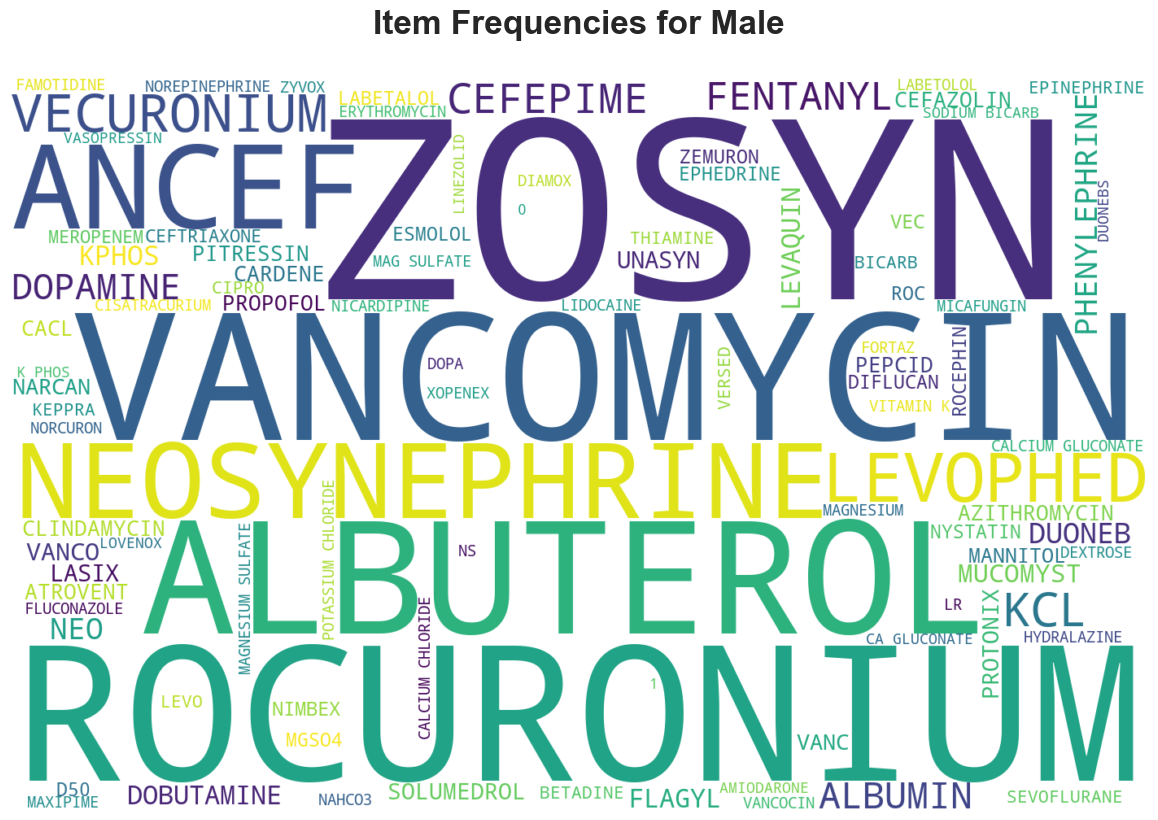

In [52]:
plot.plot_item_wordcloud(df_m_cox.Meds, title="Item Frequencies for Male", bg_color="white")

### Female

In [53]:
# NaN check
df_f_cox.Meds.isna().any()

np.False_

In [54]:
u.get_top_frequencies(df_f_cox, 'Meds', top_n=10, sep=",")

╭─ Meds ───────────────────────────────────────────────────────────────────╮
│                                                                          │
│  Frequency Distribution Ranking                                          │
│  Total Exploded Occurrences: 44,623                                      │
│                                                                          │
│     Rank      Categorical Item              Frequency      Share (%)     │
│      #1       ZOSYN                             3,866          8.66%     │
│      #2       ROCURONIUM                        2,559          5.73%     │
│      #3       VANCOMYCIN                        2,271          5.09%     │
│      #4       ALBUTEROL                         1,908          4.28%     │
│      #5       ANCEF                             1,803          4.04%     │
│      #6       NEOSYNEPHRINE                     1,731          3.88%     │
│      #7       VECURONIUM                        1,588          3.56%     │
│      #8       LEVOPHED                          1,568          3.51%     │
│      #9       KCL                               1,360          3.05%     │
│     #10       CEFEPIME                            979          2.19%     │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

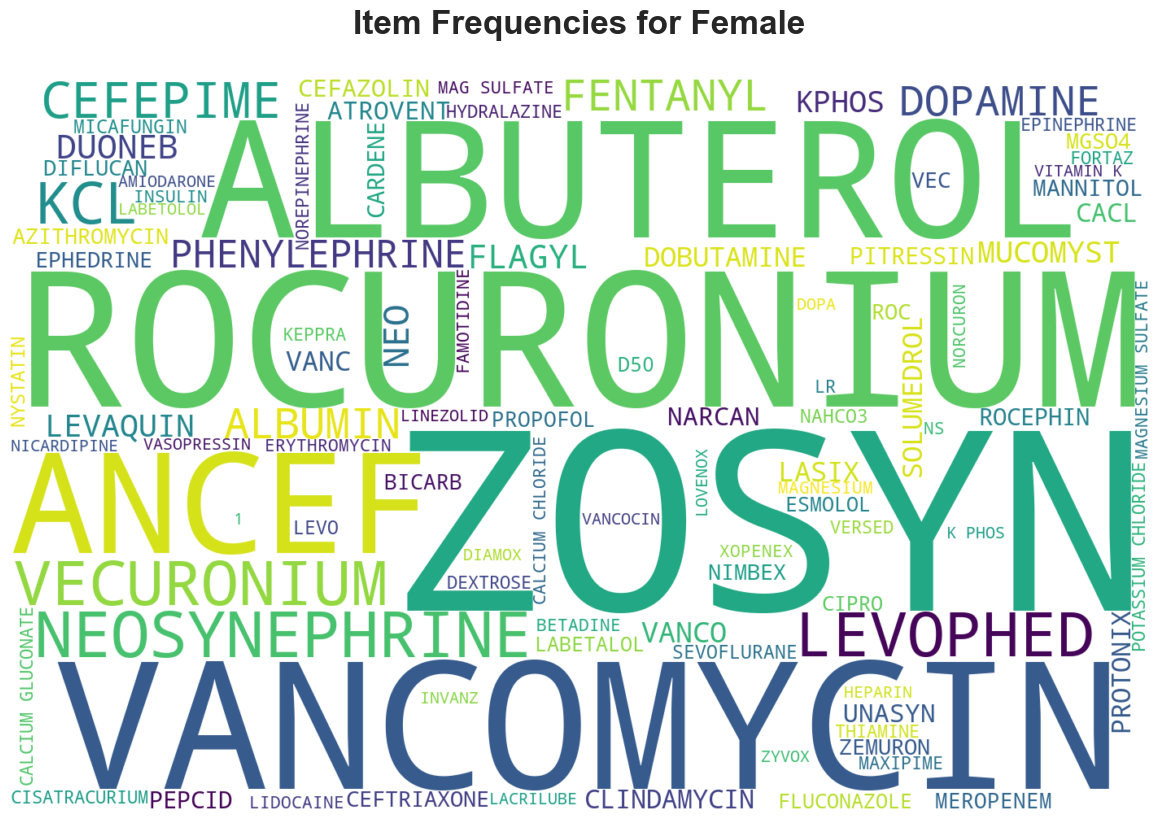

In [55]:
plot.plot_item_wordcloud(df_f_cox.Meds, title="Item Frequencies for Female", bg_color="white")

## IschemicTimeHour
* [Determining optimal donor heart ischemic times in adult cardiac transplantation](https://onlinelibrary.wiley.com/doi/full/10.1111/jocs.16558)
* [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without a blood supply before significant damage occurs is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [56]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    sns.despine(left=False, bottom=False, right=True, top=True)
    plt.tight_layout()
    plt.show()


def prepare_feature_cox(df_m, df_f, feature,
                         male_indicator=True,
                         female_indicator=True):
    """
    Cox-only preparation for one feature.
    
    Parameters
    ----------
    male_indicator   : True if male missingness is informative
    female_indicator : True if female missingness is informative
    
    Returns
    -------
    df_m_out, df_f_out
    """
    df_m_out = df_m.copy()
    df_f_out = df_f.copy()

    # Male
    if male_indicator:
        df_m_out[f'{feature}_IsMissing'] = (
            df_m_out[feature].isna().astype(int)
        )
    df_m_out[feature] = df_m_out[feature].fillna(
        df_m_out[feature].median()
    )

    # Female
    if female_indicator:
        df_f_out[f'{feature}_IsMissing'] = (
            df_f_out[feature].isna().astype(int)
        )
    df_f_out[feature] = df_f_out[feature].fillna(
        df_f_out[feature].median()
    )

    return df_m_out, df_f_out

### Male

✦ Feature Profiler │ Match: 'IschemicTimeHour_DON' │ Found: 1                     
╭──────────────────────┬─────────┬──────┬──────┬──────┬──────┬──────┬──────┬─────╮
│ Feature              │ Missing │ Mean │  Std │  Min │  25% │  50% │  75% │ Max │
├──────────────────────┼─────────┼──────┼──────┼──────┼──────┼──────┼──────┼─────┤
│ IschemicTimeHour_DON │     165 │ 3.22 │ 1.08 │ 0.30 │ 2.50 │ 3.20 │ 3.80 │  12 │
╰──────────────────────┴─────────┴──────┴──────┴──────┴──────┴──────┴──────┴─────╯

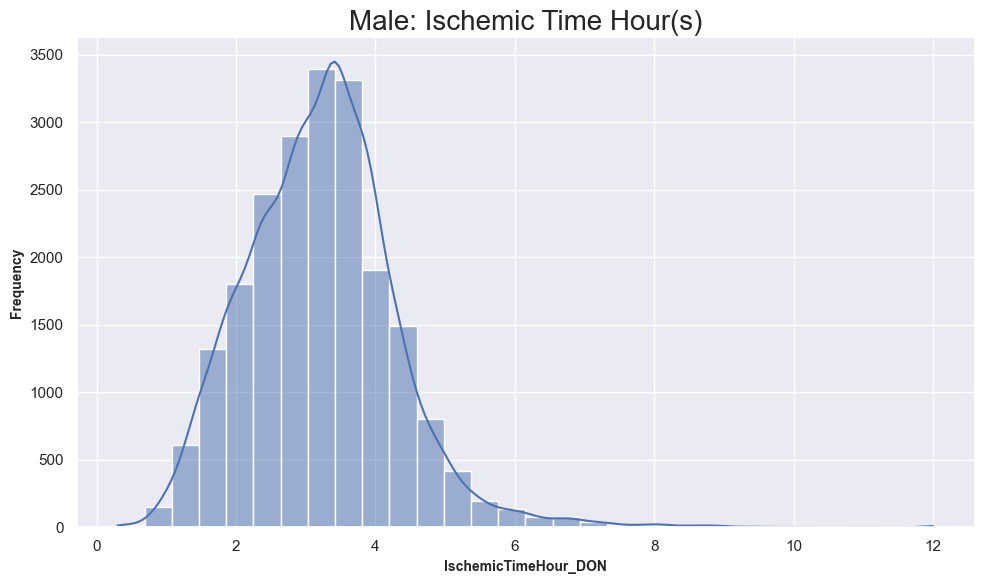

In [57]:
# info
features = u.get_feature_info(df_m_cox, 'IschemicTimeHour_DON', cat=False)
# plot
plot_histogram(df_m_cox, features[0], txt='Male: Ischemic Time Hour(s)', bins=30)

In [61]:
cim.check_informative_missingness(df, 'IschemicTimeHour_DON', txt='Male', max_categories=10)

╭─ ⚙ Informative Missingness Log (Male): IschemicTimeHour_DON ────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Cohort Overview (Male)                                                                                         │
│    Cohort Group                 Group Sizes           Mean Survival                                             │
│    Unknown / Missing            Unknown=216                1,261.4d                                             │
│    Known / Complete            Known=30,084                1,434.6d                                             │
│  Difference:            -173.2 days                                                                             │
│                                                                                                                 │
│  ──────────────────────────────────────────────────────────                                                     │
│                                                                                                                 │
│  Part 1: Outcome Relationship (Welch's t-test)                                                                  │
│  p (raw):  0.0518                                                                                               │
│                                                                                                                 │
│  ✔ RANDOM MISSINGNESS DETECTED                                                                                  │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).                                 │
│                                                                                                                 │
│  Cohen's Analysis                                                                                               │
│  Cohen's d:             -0.1499 (Negligible)                                                                    │
│  95% CI:                [-0.2837, -0.0160]                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  ──────────────────────────────────────────────────────────                                                     │
│                                                                                                                 │
│  Part 2: Predictor Relationship (MAR check)                                                                     │
│    Predictor             Test                        n    p (bonferroni)                Effect       Flag       │
│    BloodPH_DON           Mann-Whitney U         30,223            0.4076         0.114 (Small)        No        │
│    LungPO2_FIO2_DON      Mann-Whitney U         30,114            1.0000                -0.088        No        │
│                                                                                   (Negligible)                  │
│    BloodUreaNitrogen…    Mann-Whitney U         30,246            1.0000    0.068 (Negligible)        No        │
│    Weight_kg_DON         Mann-Whitney U         30,297            1.0000    0.062 (Negligible)        No        │
│    SyntheticAntiDiur…    Chi-square             30,300            0.0000    0.060 (Negligible)      p-only      │
│                          (sparse)                                                                               │
│    InsulinManagement…    Chi-square             30,300            0.0000    0.059 (Negligible)      p-only      │
│                          (sparse)                                                                               │
│    BMI_Donation_DON      Mann-Whitney U         30,291

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m_cox, features[0], txt='Male')

### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'IschemicTimeHour_DON', cat=False)

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f_cox,  features[0], txt='Female')

#### 📌 Note:

> The female cohort demonstrated evidence of informative missingness: recipients with unrecorded donor ischemic times ($n = 51$) experienced a clinically meaningful baseline survival deficit of approximately 332 days compared to the complete-case cohort. Although the standardized effect size was small (Cohen's $d = −0.287$), its 95% confidence interval strictly excluded zero ($[−0.56, −0.01]$), justifying the retention of a female-specific missingness indicator. However, given the small sample size of the missing cohort and an upper confidence bound approaching zero, the true population effect may range from negligible to moderately adverse.

> In contrast, the male cohort exhibited a much smaller raw survival discrepancy (−123 days) with a negligible, non-significant effect size (Cohen's $d = −0.107$; 95% CI spanned zero), indicating that missingness carries no independent prognostic information in males. Collectively, these findings suggest that the predictive value of ischemic-time missingness is sexually dimorphic, showing an informative signal uniquely preserved within the female architecture.

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# Create the binary flag exclusively for the female cohort 
# (Since male missingness was proven to be pure, uninformative MCAR noise)
# Impute each cohort independently using its own median
df_m_cox, df_f_cox = prepare_feature_cox(df_m_cox, df_f_cox, features[0], male_indicator=False, female_indicator=True)
df_m_cox_class, df_f_clf = prepare_feature_cox(df_m_clf, df_f_clf, features[0], male_indicator=False, female_indicator=True)

## PO2 & P02/FI02
* The UNOS dataset variables LungPO2_DON (donor partial pressure of oxygen) and LungPO2_FIO2_DON (donor fraction of inspired oxygen) are critical donor lung quality metrics used to calculate the ratio. These metrics help assess pulmonary function and graft suitability. They are crucial in assessing early graft function and donor risk.
* [Lung PCO2](https://www.ncbi.nlm.nih.gov/books/NBK551648/) (Partial Pressure of Carbon Dioxide)
* A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and CO2 becomes impaired, the PCO2 level may increase. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
* The normal range for the partial pressure of carbon dioxide (PCO2) in arterial blood is typically between 35 and 45 mmHg
* Based on current clinical literature, the assertion that "no sex-specific thresholds exist" is largely true for routine clinical practice, despite evidence that biological sex influences $CO_2$ perception and physiological levels.  

### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'LungPO2_DON|LungPO2_FIO2_DON', cat=False)

### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'LungPO2_DON|LungPO2_FIO2_DON', cat=False)

In [ ]:
# data Dictionary Search
u.dictionary_search(df_dict, features)


In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.check_informative_missingness(df_f_cox, features[2], txt='Female')
u.check_informative_missingness(df_m_cox, features[2], txt='Male')

In [ ]:
u.continuous_value_predicts_survival(df_f_cox,  features[0], txt='Female')
u.continuous_value_predicts_survival(df_m_cox,  features[0], txt='Male')
u.continuous_value_predicts_survival(df_f_cox,  features[2], txt='Female')
u.continuous_value_predicts_survival(df_m_cox,  features[2], txt='Male')

#### ⚠️ Note:
> For a heart transplant, donor lung oxygenation is largely irrelevant to graft outcome; therefore, these three features will be removed.

In [ ]:
# remove
df_m_cox = df_m_cox.drop(columns=features).copy()
df_f_cox = df_f_cox.drop(columns=features).copy()

##### User Function(s)

## OrganRecovery_PCO2
* Research indicates that there are significant gender-based differences in physiological parameters related to organ recovery, such as peak oxygen consumption $VO_2$ (oxygen consumption) and carbon dioxide metabolism, which are often influenced by differences in hemoglobin mass, blood volume, and lung function.
* Carbon Dioxide Metabolism Differences: Studies on CO clearance have shown that females have a shorter half-time for removal, but this is largely due to lower total hemoglobin mass $(Hb_{TOT})$ and differing alveolar ventilation rates.
* End-Tidal $CO_2$ $(PETCO_2)$: Resting $PETCO_2$ (End-tidal Carbon Dioxide Pressure) has been found to be significantly higher in males than in females.
* Venous-to-Arterial $PCO_2$ Differences: While $PCO_2$ gaps are monitored to predict complications, they are often used to gauge cardiac output and tissue oxygenation, and while not consistently showing a gender difference in every study, they serve as crucial metrics to manage metabolic acidosis during recovery.
* Respiratory Limitations: Women generally have smaller lung capacities and vital capacity, resulting in lower maximal tidal volume during recovery and a greater reliance on increased respiratory rate to maintain adequate alveolar ventilation.
* Clinical Implications: These differences mean that women may reach lower $VO_2$ levels before benefiting from transplantation compared to men.

### Male

In [ ]:
features = u.get_feature_info(df_m_cox, 'OrganRecovery_PCO2', cat=False)
plot_histogram(df_m_cox, features[0], txt='Male: OrganRecovery_PCO2', bins=30)

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m_cox, features[0], txt='Male')

In [ ]:
plot.plot_survival_trend(df_m_cox,  features[0], 'TransplantSurvivalDay', window_size=500)

In [ ]:
# data Dictionary Search
u.dictionary_search(df_dict, features)

#### Binning to confirm a real drop

In [ ]:
df_m_cox["pco2_bin"] = pd.cut(df_m_cox["OrganRecovery_PCO2_DON"],
                          bins=[0,25,30,35,40,45,50,120])
result = df_m_cox.groupby("pco2_bin", observed=True)["TransplantSurvivalDay"].agg(["mean","count","median"])
print(result)
# remove 
df_m_cox = df_m_cox.drop(columns=["pco2_bin"]).copy()

#### 📌 Note:
> The lowest bin ($PCO_2$ < 25 mmHg, n = 244) showed slightly lower mean survival than the 25–30 mmHg bin. However, this does not alter the overall monotonic decline in survival across the clinically relevant range, suggesting that the primary association is broadly linear with only minor deviation at the extreme lower tail.

### Female

In [ ]:
features = u.get_feature_info(df_f_cox, 'OrganRecovery_PCO2', cat=False)
plot_histogram(df_f_cox, features[0], txt='Female: OrganRecovery_PCO2', bins=30)

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f_cox, features[0], txt='Female')

#### 📌 Note:
> The distributions are nearly identical between sexes, female median 37 vs male 38, female IQR 33–41 vs male 34–42.5, both std $\approx$ 7, both centered in the normal arterial range (35–45). So the value distribution behaves the same way it did in males. 
> Given the consistent direction with the male cohort and a moderate point estimate (Cohen's d = −0.39), a binary missingness indicator was retained as a precautionary feature despite insufficient power to confirm informative missingness (n=23 missing, 95% CI crosses zero).

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# Create the binary flag exclusively for the female cohort 
# (Since male missingness was proven to be pure, uninformative MCAR noise)
# Impute each cohort independently using its own median
df_m_cox, df_f_cox = prepare_feature_cox(df_m_cox, df_f_cox, features[0], male_indicator=True, female_indicator=True)
df_m_clf, df_f_clf = prepare_feature_cox(df_m_clf, df_f_clf, features[0], male_indicator=True, female_indicator=True)

## BloodPH
* There are minor, statistically significant differences in blood pH levels between genders, though both fall within the normal range of 7.35 to 7.45. Research indicates that females tend to have a slightly higher arterial blood pH (more basic) and lower partial pressure of carbon dioxide $(PaCO_2)$ compared to males.
* The subtle differences in blood pH between genders are likely due to a combination of hormonal (estrogen), genetic (X chromosome), and physiological factors, such as differences in metabolism and respiration.
* Human blood pH is strictly regulated between 7.35 and 7.45. A pH of 6.8 (severe acidosis) and 7.8 (severe alkalosis) represent the extreme compatible limits of human life. Excursions outside these boundaries result in protein denaturation, cellular failure, and, without rapid medical intervention, death.

### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'BloodPH', cat=False)
plot_histogram(df_m_cox, features[0], txt='Male: Blood PH', bins=30)

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m_cox, features[0], txt='Male')

In [ ]:
# Inspect extreme values
low_ph_m = df_m_cox[df_m_cox['BloodPH_DON'] < 7.0]['BloodPH_DON']
# A blood pH of 5.0 is physiologically incompatible with life — the realistic range for a viable donor is approximately 7.0 to 7.7. 
# This minimum is possiblly a data entry error or coding artifact or critically ill or decesed donor
print(low_ph_m.value_counts())

In [ ]:
# Inspect extreme values
high_ph_m = df_m_cox[df_m_cox['BloodPH_DON'] > 7.8]['BloodPH_DON']
# A blood pH of 8.0 is physiologically incompatible with life — the realistic range for a viable donor is approximately 7.0 to 7.7. 
# This maximum is possiblly a data entry error or coding artifact or critically ill or decesed donor
print(high_ph_m.value_counts())

```
DBD donor:
    Brain dead but heart still beating
    Organs perfused until procurement
    pH typically maintained near normal
    Warm ischemia minimal

DCD donor:
    Life support withdrawn
    Circulatory arrest occurs
    Organs unperfused during dying process
    Warm ischemia begins immediately
    Lactic acidosis develops rapidly
    pH can drop significantly before procurement
```

In [ ]:
# Check whether low-pH donors cluster with other markers of
# poor donor condition
low_ph_mask_m = df_m_cox['BloodPH_DON'] < 6.8
high_ph_mask_m = df_m_cox['BloodPH_DON'] > 7.8

# Do they have worse recipient survival?
print(df_m_cox.groupby(low_ph_mask_m)['TransplantSurvivalDay'].mean())

# Do they cluster with high creatinine or long ischemic time?
print(df_m_cox.groupby(low_ph_mask_m)[['Creatinine_DON',
                                      'IschemicTimeHour_DON']].mean())

# Are they DCD donors specifically?
if 'donor_type' in df_m_cox.columns:
    print(pd.crosstab(low_ph_mask_m, df_m_cox['donor_type']))

In [ ]:
# data Dictionary Search
u.dictionary_search(df_dict, ['DeceasedRetyped_DON', 'CauseOfDeath_DON', 'DeathCircumstance_DON', 'BloodPH_DON'])

In [ ]:
df_m_cox.loc[low_ph_mask_m | high_ph_mask_m, ['DeceasedRetyped_DON', 'CauseOfDeath_DON', 'DeathCircumstance_DON', 'IschemicTimeHour_DON', 'BloodPH_DON']]

### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'BloodPH', cat=False)
plot_histogram(df_f_cox, features[0], txt='Female: Blood PH', bins=30)

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f_cox,features[0], txt='Female')

In [ ]:
# Inspect extreme values
low_ph_f = df_f_cox[df_f_cox['BloodPH_DON'] < 7.0]['BloodPH_DON']
# A blood pH of 5.0 is physiologically incompatible with life — the realistic range for a viable donor is approximately 7.0 to 7.7. 
# This minimum is possiblly a data entry error or coding artifact or critically ill or decesed donor
print(low_ph_f.value_counts())

# Inspect extreme values
high_ph_f = df_f_cox[df_f_cox['BloodPH_DON'] > 7.8]['BloodPH_DON']
# A blood pH of 8.0 is physiologically incompatible with life — the realistic range for a viable donor is approximately 7.0 to 7.7. 
# This maximum is possiblly a data entry error or coding artifact or critically ill or decesed donor
print(high_ph_f.value_counts())

In [ ]:
# Check whether low-pH donors cluster with other markers of
# poor donor condition
low_ph_mask_f = df_f_cox['BloodPH_DON'] < 6.8
high_ph_mask_f = df_f_cox['BloodPH_DON'] > 7.8

# Do they have worse recipient survival?
print(df_f_cox.groupby(low_ph_mask_f)['TransplantSurvivalDay'].mean())

# Do they cluster with high creatinine or long ischemic time?
print(df_f_cox.groupby(low_ph_mask_f)[['Creatinine_DON',
                                      'IschemicTimeHour_DON']].mean())

# Are they DCD donors specifically?
if 'donor_type' in df_f_cox.columns:
    print(pd.crosstab(low_ph_mask_f, df_f_cox['donor_type']))

In [ ]:
df_f_cox.loc[low_ph_mask_f | high_ph_mask_f, ['DeceasedRetyped_DON', 'CauseOfDeath_DON', 'DeathCircumstance_DON', 'IschemicTimeHour_DON', 'BloodPH_DON']]

#### 📌 Note:
> BloodPH_DON exhibited sex-specific missingness behavior. In the male cohort, 57 missing observations were associated with a 585.9-day reduction in mean survival, a highly significant Welch’s test, and a medium effect size (Cohen’s d = −0.507, 95% CI excluding zero), indicating that missingness itself carries independent prognostic information. A male-specific missingness indicator was therefore retained. In the female cohort, 20 missing observations were associated with a 409.6-day survival deficit; however, the result did not reach conventional significance (p = 0.061), and the effect-size confidence interval crossed zero (Cohen’s d = −0.355, 95% CI [−0.793, 0.084]). Evidence for informative missingness was therefore insufficient, and no female indicator was created. Missing values in both cohorts were subsequently imputed using the cohort median.

> Outlier analysis identified two distinct data-quality patterns. Sixteen observations below pH 6.8 (12 male, 4 female) were determined to be registry artifacts rather than true physiologic measurements. All originated from DBD donors, making pH values between 5.0 and 6.5 incompatible with maintained organ viability. This conclusion was supported by three independent findings: recipients exhibited unusually favorable survival (mean 2,291 days), donor creatinine and ischemic times were comparable to the normal-pH cohort, and values clustered at rounded increments (5.0, 5.5, 6.0, 6.5), consistent with transcription or default-entry errors. Several records also contained a DeceasedRetyped flag. These values were converted to missing after creation of the missingness indicator to avoid conflating data-quality corrections with originally missing observations.

> In contrast, extremely high-pH values were retained. Three male observations at pH above 7.8 were associated with markedly reduced survival (mean: 572 days) and elevated donor creatinine (mean: 3.96 mg/dL), consistent with severe physiologic instability. One female observation at pH 7.82 showed elevated creatinine (2.33 mg/dL) and was retained to ensure consistent cleaning criteria across cohorts. No upper-bound truncation was applied.

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# Apply consistent rules across sexes
# Lower bound confirmed at 6.8 for both
# Upper bound — same as males, no cap
df_f_cox['BloodPH_DON'] = df_f_cox['BloodPH_DON'].where(
    df_f_cox['BloodPH_DON'] >= 6.8, np.nan
)
df_m_cox['BloodPH_DON'] = df_m_cox['BloodPH_DON'].where(
    df_m_cox['BloodPH_DON'] >= 6.8, np.nan
)
#  Apply the same rules to the classification datasets
df_f_clf['BloodPH_DON'] = df_f_clf['BloodPH_DON'].where(
    df_f_clf['BloodPH_DON'] >= 6.8, np.nan
)
df_m_clf['BloodPH_DON'] = df_m_clf['BloodPH_DON'].where(
    df_m_clf['BloodPH_DON'] >= 6.8, np.nan
)


# Impute each cohort independently using its own median
df_m_cox, df_f_cox = prepare_feature_cox(df_m_cox, df_f_cox, features[0], male_indicator=True, female_indicator=True)
df_m_clf, df_f_clf = prepare_feature_cox(df_m_clf, df_f_clf, features[0], male_indicator=True, female_indicator=True)

## Level_SGOT
* In clinical practice, males generally have higher absolute levels of both AST (SGOT) and ALT (SGPT) compared to females. However, because ALT levels are significantly lower in women, females typically have a higher AST/ALT ratio.
* ALT Specificity: ALT is more heavily influenced by gender than AST. In healthy adults, median ALT levels can be 20% higher in men than in women.
* The AST/ALT Ratio: Even though women have lower absolute numbers, their ALT is disproportionately lower than their AST. This results in a higher "De Ritis" ratio in females (median $\approx$ 0.90) compared to males (median $\approx$ 0.81) when healthy.

### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'Level_SGOT', cat=False)
plot.plot_histogram(df_m_cox, features,  txt='Male: Level SGOT')

#### Are the extreme values real or entry errors?

In [ ]:
# Check high-end outliers
for col in ['Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON']:
    extreme = df_m_cox[df_m_cox[col] > 5000]
    print(f"\n{col} > 5000:")
    print(extreme[['DeceasedRetyped_DON', 'CauseOfDeath_DON',
                    col, 'TransplantSurvivalDay']].head(10).to_string(index=False))

#### Are the near-zero values real?

In [ ]:
# Check low-end outliers
for col in ['Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON']:
    low = df_m_cox[df_m_cox[col] < 5]
    print(f"\n{col} < 5:")
    print(low[[col, 'TransplantSurvivalDay', 'Creatinine_DON']].describe())

In [ ]:
# Collinearity between ALT and AST
r, p = stats.pearsonr(
    df_m_cox['Level_SGOT_ALT_DON'].dropna(),
    df_m_cox['Level_SGOT_AST_DON'].dropna()
)
print(f"Male - ALT-AST correlation: r={r:.3f}, p={p:.2e}")

In [ ]:
for feature in features:
    u.check_informative_missingness(df_m_cox, feature, txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'Level_SGOT', cat=False)
plot.plot_histogram(df_f_cox, features,  txt='Female: Level SGOT')

In [ ]:
for feature in features:
    u.check_informative_missingness(df_f_cox, feature, txt='Female')

In [ ]:
# data Dictionary Search
u.dictionary_search(df_dict, features)

In [ ]:
# Collinearity between ALT and AST
r, p = stats.pearsonr(
    df_f_cox['Level_SGOT_ALT_DON'].dropna(),
    df_f_cox['Level_SGOT_AST_DON'].dropna()
)
print(f"Female-ALT-AST correlation: r={r:.3f}, p={p:.2e}")

#### New Feature

In [ ]:
# New Feature: AST/ALT
df_m_cox['Level_SGOT_Ratio'] =  df_m_cox.Level_SGOT_AST_DON / df_m_cox.Level_SGOT_ALT_DON
df_f_cox['Level_SGOT_Ratio'] =  df_f_cox.Level_SGOT_AST_DON / df_f_cox.Level_SGOT_ALT_DON
# Apply the same feature to the classification datasets
df_m_clf['Level_SGOT_Ratio'] =  df_m_clf.Level_SGOT_AST_DON / df_m_clf.Level_SGOT_ALT_DON
df_f_clf['Level_SGOT_Ratio'] =  df_f_clf.Level_SGOT_AST_DON / df_f_clf.Level_SGOT_ALT_DON

In [ ]:
# Check for zero or near-zero ALT values
print((df_m_cox['Level_SGOT_ALT_DON'] == 0).sum())
print((df_f_cox['Level_SGOT_ALT_DON'] == 0).sum())

# Check resulting infinite or NaN ratio values
print(df_m_cox['Level_SGOT_Ratio'].isna().sum())
print(df_m_cox['Level_SGOT_Ratio'].isin([np.inf, -np.inf]).sum())

In [ ]:
for col in ['Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON']:
    print(f"\n{col} < 5 (male):")
    print(df_m_cox[df_m_cox[col] < 5][col].value_counts().sort_index())
    
    print(f"\n{col} < 5 (female):")
    print(df_f_cox[df_f_cox[col] < 5][col].value_counts().sort_index())

In [ ]:
for col in ['Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON']:
    low_mask = df_m_cox[col] < 5
    print(f"\n{col} low vs normal survival (male):")
    print(df_m_cox.groupby(low_mask)['TransplantSurvivalDay'].mean())

In [ ]:
for col in ['Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON']:
    low_mask = df_f_cox[col] < 5
    print(f"\n{col} low vs normal survival (female):")
    print(df_f_cox.groupby(low_mask)['TransplantSurvivalDay'].mean())

#### 📌 Note:

| Group          | GroupLow Survival | Normal Survival | Interpretation  |
| -------------- | ----------------- | --------------- | --------------- |
| Male ALT < 5   | 1,507d            | 1,431d          | Slightly better |
| Male AST < 5   | 1,717d            | 1,430d          | Better          |
| Female ALT < 5 | 1,160d            | 1,440d          | Worse           |
| Female AST < 5 | 1,318d            | 1,440d          | Worse           |


We cannot establish that these observations are erroneous. Although some values fall below typical laboratory detection limits, the available evidence is insufficient to distinguish true low measurements from recording artifacts. Consequently, the observations were retained without modification.

In [ ]:
# Is the ratio predictive?
for cohort, df in [('Male', df_m_cox), ('Female', df_f_cox)]:
    r, p = stats.spearmanr(
        df['Level_SGOT_Ratio'].dropna(),
        df.loc[df['Level_SGOT_Ratio'].notna(), 'TransplantSurvivalDay']
    )
    print(f"{cohort} SGOT Ratio — Spearman r={r:.3f}, p={p:.2e}")

In [ ]:
# What does the ratio distribution look like?
for cohort, df in [('Male', df_m_cox), ('Female', df_f_cox)]:
    print(f"\n{cohort} SGOT Ratio:")
    print(df['Level_SGOT_Ratio'].describe())

### The "Shadow Variable" (Indicator) + Median Imputation + Log Transform

In [ ]:
# Missingness indicator - males only
df_m_cox['Level_SGOT_IsMissing'] = df_m_cox['Level_SGOT_Ratio'].isna().astype(int)
df_m_clf['Level_SGOT_IsMissing'] = df_m_clf['Level_SGOT_Ratio'].isna().astype(int)
# No female indicator - MCAR confirmed

# Median fill
df_m_cox['Level_SGOT_Ratio'] = df_m_cox['Level_SGOT_Ratio'].fillna(
    df_m_cox['Level_SGOT_Ratio'].median()
)
df_f_cox['Level_SGOT_Ratio'] = df_f_cox['Level_SGOT_Ratio'].fillna(
    df_f_cox['Level_SGOT_Ratio'].median()
)
# Fill missing values in the classification datasets
df_m_clf['Level_SGOT_Ratio'] = df_m_clf['Level_SGOT_Ratio'].fillna(
    df_m_clf['Level_SGOT_Ratio'].median()
)
df_f_clf['Level_SGOT_Ratio'] = df_f_clf['Level_SGOT_Ratio'].fillna(
    df_f_clf['Level_SGOT_Ratio'].median()
)

# Log transform - required given extreme right skew
df_m_cox['Level_SGOT_Ratio_log'] = np.log1p(df_m_cox['Level_SGOT_Ratio'])
df_f_cox['Level_SGOT_Ratio_log'] = np.log1p(df_f_cox['Level_SGOT_Ratio'])
df_m_clf['Level_SGOT_Ratio_log'] = np.log1p(df_m_clf['Level_SGOT_Ratio'])
df_f_clf['Level_SGOT_Ratio_log'] = np.log1p(df_f_clf['Level_SGOT_Ratio'])

# Drop original ALT and AST columns
df_m_cox.drop(columns=features, inplace=True)
df_f_cox.drop(columns=features, inplace=True)
df_m_clf.drop(columns=features, inplace=True)
df_f_clf.drop(columns=features, inplace=True)

# remove
remove_cols = ['Level_SGOT_Ratio']
df_m_cox = df_m_cox.drop(columns=remove_cols)
df_f_cox = df_f_cox.drop(columns=remove_cols)
df_m_clf = df_m_clf.drop(columns=remove_cols)
df_f_clf = df_f_clf.drop(columns=remove_cols)   

In [ ]:
# Plots
plot_histogram(df_m_cox, 'Level_SGOT_Ratio_log', txt='(Male)', bins=30)

In [ ]:
# Plots
plot_histogram(df_f_cox, 'Level_SGOT_Ratio_log', txt='(Female)', bins=30)

#### 📌 Note:

Level_SGOT_ALT_DON and Level_SGOT_AST_DON exhibited identical missingness profiles within each sex, consistent with both variables originating from the same donor data. In males, 43 missing cases were associated with a 465.1-day survival deficit, a significant Welch’s test (p = 0.016), and a small but meaningful effect size (Cohen’s d = −0.402, 95% CI [−0.702, −0.103]), indicating informative missingness. A single shared indicator (SGOT_missing) was therefore created for the male cohort. In females, 15 missing cases showed a 353.7-day survival deficit that did not reach statistical significance (p = 0.204), and the confidence interval spanned zero (Cohen’s d = −0.306, 95% CI [−0.813, 0.200]), providing insufficient evidence that missingness carried independent prognostic information. No female indicator was created. Missing values in both cohorts were imputed using the cohort-specific median.

The relationship between ALT and AST differed by sex. In males, the correlation was moderate (Pearson r = 0.532), whereas in females it exceeded the predefined collinearity threshold (r = 0.715). To address collinearity while maintaining a consistent feature representation across sex-stratified models, the individual ALT and AST variables were replaced with the AST/ALT ratio in both cohorts. The derived ratio retained prognostic information, showing statistically significant associations with survival in both males (Spearman r = 0.091, p = 2.46 × 10⁻⁴⁰) and females (Spearman r = 0.040, p = 1.39 × 10⁻⁴).

Low-end observations (<5) were identified in both variables across both cohorts. Although some values fell below typical laboratory detection limits, value frequencies showed no clear clustering indicative of default-entry errors, and the available evidence was insufficient to distinguish true low measurements from recording artifacts. Consequently, these observations were retained without modification.

The AST/ALT ratio exhibited substantial right skew in both cohorts, with extreme values primarily driven by low ALT denominators. A log1p transformation was applied after imputation to improve distributional stability for proportional hazards modeling. Following the ratio derivation, the original ALT and AST variables were removed from both model matrices.

## Terminal Total Bilirubin
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'TerminalTotalBilirubin_DON', cat=False) 
plot_histogram(df_m_cox, features[0], txt='Male: Terminal Total Bilirubin', bins=30)

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m_cox,features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'TerminalTotalBilirubin_DON', cat=False) 
plot_histogram(df_f_cox,  features[0], txt='Female: Terminal Total Bilirubin', bins=30)

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f_cox,features[0], txt='Female')

Interesting coincidence worth checking
Male TerminalTotalBilirubin_DON has identical missingness stats to Level_SGOT (n=43, −465.1d, d=−0.402, p=0.016). Are these missing in the same rows?

In [ ]:
bili_missing_m = df_m_cox['TerminalTotalBilirubin_DON'].isna()
sgot_missing_m = df_m_cox['Level_SGOT_IsMissing'] == 1
print((bili_missing_m & sgot_missing_m).sum())  # overlap
print((bili_missing_m == sgot_missing_m).all())  # perfectly collinear?

#### Log Transform

In [ ]:
# Log Transform
df_m_cox['TerminalTotalBilirubin_Log'] = np.log1p(df_m_cox[features[0]])
df_m_clf['TerminalTotalBilirubin_Log'] = np.log1p(df_m_clf[features[0]])
# female
df_f_cox['TerminalTotalBilirubin_Log'] = np.log1p(df_f_cox[features[0]])
df_f_clf['TerminalTotalBilirubin_Log'] = np.log1p(df_f_clf[features[0]])
# remove
df_m_cox = df_m_cox.drop(features[0], axis=1)
df_f_cox = df_f_cox.drop(features[0], axis=1)
df_m_clf = df_m_clf.drop(features[0], axis=1)
df_f_clf = df_f_clf.drop(features[0], axis=1)

In [ ]:
plot_histogram(df_m_cox, 'TerminalTotalBilirubin_Log', txt='Female: Terminal Total Bilirubin Log', bins=30)

#### Median Imputation

TerminalTotalBilirubin_Log was imputed using the cohort-specific median. No missingness indicator was created because bilirubin missingness is a strict subset of Level_SGOT_IsMissing in both cohorts since every row missing bilirubin is also missing SGOT (male: perfectly collinear, n=43; female: 14 of 15 missing rows overlap, with one discrepant row where SGOT was missing but bilirubin was recorded). A separate indicator would be nearly perfectly collinear with the existing one, adding redundancy without a new predictive signal.

In [ ]:
# Median imputation
df_m_cox['TerminalTotalBilirubin_Log'] = df_m_cox.TerminalTotalBilirubin_Log.fillna(df_m_cox.TerminalTotalBilirubin_Log.median())
df_m_clf['TerminalTotalBilirubin_Log'] = df_m_clf.TerminalTotalBilirubin_Log.fillna(df_m_clf.TerminalTotalBilirubin_Log.median())
# female
df_f_cox['TerminalTotalBilirubin_Log'] = df_f_cox.TerminalTotalBilirubin_Log.fillna(df_f_cox.TerminalTotalBilirubin_Log.median())
df_f_clf['TerminalTotalBilirubin_Log'] = df_f_clf.TerminalTotalBilirubin_Log.fillna(df_f_clf.TerminalTotalBilirubin_Log.median())

## [Blood Urea Nitrogen Level](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
*  Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source reports a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'BloodUreaNitrogenLevel', cat=False)
plot_histogram(df_m_cox, features[0], txt='Male: Blood Urea Nitrogen Level', bins=30)

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m_cox,features[0], txt='Male')

In [ ]:
plot.plot_transform_distribution(df_m_cox[features[0]], txt='Blood Urea Nitrogen Level (Male)')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'BloodUreaNitrogenLevel', cat=False) 
plot_histogram(df_f_cox, features[0], txt='Female: Blood Urea Nitrogen Level', bins=30)

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f_cox, features[0], txt='Female')

In [ ]:
plot.plot_transform_distribution(df_f_cox[features[0]], txt='Blood Urea Nitrogen Level (Female)')

#### Log Transform

In [ ]:
# Log Transform
df_m_cox['BloodUreaNitrogenLevel_Log'] = np.log1p(df_m_cox[features[0]])
df_m_clf['BloodUreaNitrogenLevel_Log'] = np.log1p(df_m_clf[features[0]])
# female
df_f_cox['BloodUreaNitrogenLevel_Log'] = np.log1p(df_f_cox[features[0]])
df_f_clf['BloodUreaNitrogenLevel_Log'] = np.log1p(df_f_clf[features[0]])
# remove
df_m_cox = df_m_cox.drop(features[0], axis=1)
df_f_cox = df_f_cox.drop(features[0], axis=1)
df_m_clf = df_m_clf.drop(features[0], axis=1)
df_f_clf = df_f_clf.drop(features[0], axis=1)

#### The "Shadow Variable" (Indicator) + Median Imputationm

* BloodUreaNitrogenLevel_DON is the strongest continuous predictor observed to date, with Spearman’s r ≈ −0.20 ($R^2$ $\approx$ 4%) across both cohorts, consistent in direction and magnitude by sex and indicative of a modest but stable biological association with survival.

* Missingness patterns differ by sex. In the male cohort, missingness is strongly associated with survival outcomes (Cohen’s d = −0.530, 95% CI excluding zero, −612.5-day survival difference), indicating informative missingness and motivating inclusion of a corresponding shadow indicator in downstream modeling.

* In contrast, the female cohort shows no detectable association between missingness and survival (Cohen’s d = −0.186, 95% CI [−0.693, 0.320], p = 0.515), suggesting that missingness does not contribute additional predictive signal beyond observed variables. Accordingly, no shadow indicator is retained for the female subgroup, and missing values are imputed using the cohort median.

In [ ]:
# impute: median and use new feature for NANS
df_m_cox['BloodUreaNitrogenLevel_IsMissing'] = df_m_cox.BloodUreaNitrogenLevel_Log.isna().astype(int)
df_m_clf['BloodUreaNitrogenLevel_IsMissing'] = df_m_clf.BloodUreaNitrogenLevel_Log.isna().astype(int)
# median
df_m_cox['BloodUreaNitrogenLevel_Log'] = df_m_cox.BloodUreaNitrogenLevel_Log.fillna(df_m_cox.BloodUreaNitrogenLevel_Log.median())
df_f_cox['BloodUreaNitrogenLevel_Log'] = df_f_cox.BloodUreaNitrogenLevel_Log.fillna(df_f_cox.BloodUreaNitrogenLevel_Log.median())
df_m_clf['BloodUreaNitrogenLevel_Log'] = df_m_clf.BloodUreaNitrogenLevel_Log.fillna(df_m_clf.BloodUreaNitrogenLevel_Log.median())
df_f_clf['BloodUreaNitrogenLevel_Log'] = df_f_clf.BloodUreaNitrogenLevel_Log.fillna(df_f_clf.BloodUreaNitrogenLevel_Log.median())
# sanity check
df_m_cox['BloodUreaNitrogenLevel_IsMissing'].sum(), df_m_clf['BloodUreaNitrogenLevel_IsMissing'].sum()

## [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'Creatinine', cat=False) 
plot_histogram(df_m_cox, features[0], txt='Male: Creatinine', bins=30)

In [ ]:
plot.plot_transform_distribution(df_m_cox[features[0]], txt='Blood Urea Nitrogen Level (Male)')

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m_cox,features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'Creatinine', cat=False) 
plot_histogram(df_f_cox, features[0], txt='Female: Creatinine', bins=30)

In [ ]:
plot.plot_transform_distribution(df_f_cox[features[0]], txt='Blood Urea Nitrogen Level (Female)')

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f_cox,features[0], txt='Female')

#### 📌 Note:

> In the male cohort, 39 missing Creatinine_DON observations were associated with a 612.5-day reduction in mean survival, a highly significant Welch's test (p = 0.001), and a medium effect size (Cohen's d = −0.530, 95% CI [−0.844, −0.216]), providing strong evidence that missingness carries independent prognostic information. A male-specific missingness indicator was therefore retained.

> In the female cohort, 15 missing observations were associated with a 215.4-day reduction in mean survival; however, the Welch's test was not significant (p = 0.515), and the effect-size confidence interval spanned zero (Cohen's d = −0.186, 95% CI [−0.693, 0.320]). Although the point estimate suggests worse outcomes among recipients with missing donor creatinine values, the available evidence is insufficient to distinguish this effect from chance variation. No female missingness indicator was created.

In [ ]:
for cohort, df in [('Male', df_m_cox), ('Female', df_f_cox)]:
    vals = df['Creatinine_DON'].dropna()
    
    skew     = vals.skew()
    stat, p  = stats.skewtest(vals)
    kurt     = vals.kurt()
    
    print(f"\n{cohort} Creatinine_DON:")
    print(f"  Skewness:       {skew:.3f}")
    print(f"  Skew test p:    {p:.4f}")
    print(f"  Kurtosis:       {kurt:.3f}")
    print(f"  Mean/Median:    {vals.mean():.3f} / {vals.median():.3f}")
    print(f"  Std/Mean ratio: {vals.std()/vals.mean():.3f}")

Creatinine_DON exhibited substantial positive skew in both cohorts. Skewness exceeded 3.8 in males and females, far above the conventional threshold of 1.0 used to indicate severe non-normality. Kurtosis exceeded 19 in both groups, reflecting extremely heavy upper tails driven by a small number of donors with markedly elevated creatinine values. The mean also substantially exceeded the median in each cohort, further confirming a strongly right-skewed distribution. To reduce the influence of extreme values, improve distributional symmetry, and better satisfy modeling assumptions, a log1p transformation was applied following imputation.

#### The "Shadow Variable" (Indicator) + Median Imputation + Log Transform

In [ ]:
# Impute each cohort independently using its own median
df_m_cox, df_f_cox = prepare_feature_cox(df_m_cox, df_f_cox, features[0], male_indicator=True, female_indicator=False)
df_m_clf, df_f_clf = prepare_feature_cox(df_m_clf, df_f_clf, features[0], male_indicator=True, female_indicator=False)

# Log Transform
df_m_cox['Creatinine_Log'] = np.log1p(df_m_cox[features[0]])
df_m_clf['Creatinine_Log'] = np.log1p(df_m_clf[features[0]])
# female
df_f_cox['Creatinine_Log'] = np.log1p(df_f_cox[features[0]])
df_f_clf['Creatinine_Log'] = np.log1p(df_f_clf[features[0]])
# remove
df_m_cox = df_m_cox.drop(columns=features)
df_f_cox = df_f_cox.drop(columns=features)
df_m_clf = df_m_clf.drop(columns=features)
df_f_clf = df_f_clf.drop(columns=features)

## [Hematocrit](https://www.mountsinai.org/health-library/tests/hematocrit)
* Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'Hematocrit', cat=False) 

In [ ]:
plot_histogram(df_m_cox, features[0], txt='Male: Hematocrit', bins=30)

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'Hematocrit', cat=False) 

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')

In [ ]:
# Values of 75 and 1 are possibly due to an entry error, but that needs to be confirmed in the data.
print("Male Hematocrit > 55:")
#  Corrected: .to_string() is inside the print function
print(df_m_cox[df_m_cox['Hematocrit_DON'] > 55][
    ['Hematocrit_DON', 'TransplantSurvivalDay', 'Creatinine_Log',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

print("\nMale Hematocrit < 10:")
print(df_m_cox[df_m_cox['Hematocrit_DON'] < 10][
    ['Hematocrit_DON', 'TransplantSurvivalDay', 'Creatinine_Log',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

# Female extremes
print("\nFemale Hematocrit < 5:")
print(df_f_cox[df_f_cox['Hematocrit_DON'] < 5][
    ['Hematocrit_DON', 'TransplantSurvivalDay', 'Creatinine_Log',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

print("\nFemale Hematocrit > 55:")
print(df_f_cox[df_f_cox['Hematocrit_DON'] > 55][
    ['Hematocrit_DON', 'TransplantSurvivalDay', 'Creatinine_Log',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

In [ ]:
# Are low hematocrit cases systematically different?
for cohort, df in [('Male', df_m_cox), ('Female', df_f_cox)]:
    low_mask = df['Hematocrit_DON'] < 10
    print(f"\n{cohort} low vs normal survival:")
    print(df.groupby(low_mask)['TransplantSurvivalDay'].mean())
    print(f"\n{cohort} DeceasedRetyped among low:")
    print(df[low_mask]['DeceasedRetyped_DON'].value_counts())

In [ ]:
print(df_m_cox['DeceasedRetyped_DON'].value_counts(normalize=True))
print(df_f_cox['DeceasedRetyped_DON'].value_counts(normalize=True))

In [ ]:
# Verify shared missingness between Hematocrit_DON and Creatinine_DON for Male
for cohort, df in [('Male', df_m_cox)]:
    hema_missing = df['Hematocrit_DON'].isna()
    creat_missing = df['Creatinine_DON_IsMissing'] == 1
    
    print(f"\n{cohort}:")
    print(f"  Hematocrit missing: {hema_missing.sum()}")
    print(f"  Creatinine missing: {creat_missing.sum()}")
    print(f"  Identical pattern:  {(hema_missing == creat_missing).all()}")
    print(f"  Overlap:            {(hema_missing & creat_missing).sum()}")

#### Median Imputation

In [ ]:
# impute: median
df_m_cox['Hematocrit_DON'] = df_m_cox.Hematocrit_DON.fillna(df_m_cox.Hematocrit_DON.median())
df_m_clf['Hematocrit_DON'] = df_m_clf.Hematocrit_DON.fillna(df_m_clf.Hematocrit_DON.median())
# female
df_f_cox['Hematocrit_DON'] = df_f_cox.Hematocrit_DON.fillna(df_f_cox.Hematocrit_DON.median())
df_f_clf['Hematocrit_DON'] = df_f_clf.Hematocrit_DON.fillna(df_f_clf.Hematocrit_DON.median())

#### 📌 Note:

> Hematocrit_DON exhibited extreme values at both distributional tails, requiring evaluation prior to imputation. The primary concern was whether these observations represented genuine physiologic measurements from compromised donors or data-entry artifacts.

> Low-end values (male <10%, female <5%) were examined first. Recipients associated with these donors showed modestly lower mean survival than the overall cohort (males: 1,330 vs 1,432 days; females: 1,304 vs 1,441 days), a pattern consistent with clinical compromise rather than benign recording errors. Value frequencies showed no round-number clustering, survival outcomes were highly variable, and the proportion of records carrying the DeceasedRetyped flag was comparable to the full cohort. Collectively, the available evidence did not support classifying these observations as artifacts, and the values were retained.

> Upper-end values (>55%) were evaluated similarly. Male observations between 56% and 60% and female observations above 56% were associated with plausible survival outcomes and donor characteristics. One male observation at 75% was considered suspicious because of its rarity, but no independent evidence confirmed a recording error. Consequently, all upper-end observations were retained, and no truncation was applied.

> Missingness exhibited sex-specific behavior. In males, 39 observations missing for Creatinine_DON shared an identical missingness pattern, including the same cases, survival deficit, and statistical test results, indicating a common laboratory collection mechanism. Because this information was already captured by the existing Creatinine_IsMissing indicator, no additional hematocrit-specific indicator was created. In females, 14 missing observations were associated with a 406.8-day reduction in mean survival; however, the Welch’s test was not significant (p = 0.169), and the effect-size confidence interval spanned zero (Cohen’s d = −0.352, 95% CI [−0.876, 0.172]). The available evidence was therefore insufficient to conclude that missingness carried independent prognostic information. Missing values in both cohorts were imputed using the cohort-specific median.



## [LV_Ejection Fraction Percent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
* Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    * Male:
        * Normal: 52% to 72%
        * Mildly Abnormal: 41% to 51%
        * Moderately Abnormal: 30% to 40%
        * Severely Abnormal: Below 30% 
    * Female:
        * Normal: 54% to 74%
        * Mildly Abnormal: 41% to 53%
        * Moderately Abnormal: 30% to 40%
        * Severely Abnormal: Below 30% 

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'LV_EjectionFractionPercent', cat=False)
plot_histogram(df_m_cox, features[0], txt='Male: LV_Ejection Fraction Percent', bins=30)

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'LV_EjectionFractionPercent', cat=False)
plot_histogram(df_f_cox, features[0], txt='Female: LV_Ejection Fraction Percent', bins=30)

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')

In [ ]:
# Low-end investigation
print("Male EF < 20:")
print(df_m_cox[df_m_cox['LV_EjectionFractionPercent_DON'] < 20][
    ['LV_EjectionFractionPercent_DON', 'TransplantSurvivalDay',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

print("\nFemale EF < 25:")
print(df_f_cox[df_f_cox['LV_EjectionFractionPercent_DON'] < 25][
    ['LV_EjectionFractionPercent_DON', 'TransplantSurvivalDay',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

# High-end investigation
print("\nMale EF > 80:")
print(df_m_cox[df_m_cox['LV_EjectionFractionPercent_DON'] > 80][
    ['LV_EjectionFractionPercent_DON', 'TransplantSurvivalDay',
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

print("\nFemale EF > 80:")
print(df_f_cox[df_f_cox['LV_EjectionFractionPercent_DON'] > 80][
    ['LV_EjectionFractionPercent_DON', 'TransplantSurvivalDay', 
     'DeceasedRetyped_DON', 'CauseOfDeath_DON']
].to_string())

#### The "Shadow Variable" (Indicator) (Male ONLY) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m_cox['LV_EjectionFractionPercent_IsMissing'] = df_m_cox[features[0]].isna().astype(int)
df_m_clf['LV_EjectionFractionPercent_IsMissing'] = df_m_clf[features[0]].isna().astype(int)
# median
df_m_cox[features[0]] = df_m_cox[features[0]].fillna(df_m_cox[features[0]].median())
df_m_clf[features[0]] = df_m_clf[features[0]].fillna(df_m_clf[features[0]].median())
# female
df_f_cox[features[0]] = df_f_cox[features[0]].fillna(df_f_cox[features[0]].median())
df_f_clf[features[0]] = df_f_clf[features[0]].fillna(df_f_clf[features[0]].median())
# sanity check
df_m_cox['LV_EjectionFractionPercent_IsMissing'].sum(), df_m_clf['LV_EjectionFractionPercent_IsMissing'].sum()

#### 📌 Note:
> LV_EjectionFractionPercent_DON exhibited an unusual missingness pattern relative to most previously examined donor variables. In the male cohort, 25 missing observations were associated with substantially longer mean survival than complete cases (2,014.5 vs. 1,429.9 days), yielding a survival advantage of 584.6 days. The difference was statistically significant (Welch's p = 0.034) and accompanied by a medium effect size (Cohen's d = 0.506, 95% CI [0.113, 0.898]), indicating that missingness carries independent prognostic information. A male-specific missingness indicator (LV_EjectionFractionPercent_DON_IsMissing) was therefore retained.

> In the female cohort, 9 missing observations were associated with a 365.2-day survival advantage (1,805.0 vs. 1,439.8 days); however, the Welch's test was not significant (p = 0.302), and the effect-size confidence interval spanned zero (Cohen's d = 0.316, 95% CI [−0.338, 0.970]). Given the small number of missing cases and substantial uncertainty surrounding the estimate, the available evidence was insufficient to conclude that missingness carried independent prognostic information. No female missingness indicator was created.

> Outlier investigation evaluated observations above 80% and below 20% in males or 25% in females. High-end values were observed in 80 male and 33 female records, with survival outcomes spanning the full observed range and no evidence of a distinct subgroup suggestive of data-entry artifacts. Low-end observations were rare, totaling only five cases across both cohorts. Neither tail exhibited anomalous survival patterns, clustering behavior, or other evidence supporting truncation. Consequently, all observed values were retained.

> Missing values were imputed using the cohort-specific median after generating missingness indicators.


### BMI

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'BMI_', cat=False) 

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'BMI_', cat=False) 

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')

In [ ]:
# impute: median
df_m_cox[features] = df_m_cox[features].fillna(df_m_cox[features].median())
df_m_clf[features] = df_m_clf[features].fillna(df_m_clf[features].median())
# female
df_f_cox[features] = df_f_cox[features].fillna(df_f_cox[features].median())
df_f_clf[features] = df_f_clf[features].fillna(df_f_clf[features].median())

## Weight (Kg)

In [ ]:
# info
features = u.get_feature_info(df_m_cox, 'Weight', cat=False) 

In [ ]:
u.check_informative_missingness(df_m_cox, features[0], txt='Male')

In [ ]:
# info
features = u.get_feature_info(df_f_cox, 'Weight', cat=False) 

In [ ]:
u.check_informative_missingness(df_f_cox, features[0], txt='Female')

In [ ]:
# impute: median
df_m_cox[features] = df_m_cox[features].fillna(df_m_cox[features].median())
df_m_clf[features] = df_m_clf[features].fillna(df_m_clf[features].median())
# female
df_f_cox[features] = df_f_cox[features].fillna(df_f_cox[features].median())
df_f_clf[features] = df_f_clf[features].fillna(df_f_clf[features].median())

### OtherMedsText1_DON & OtherMedsText2_DON & OtherMedsText3_DON

#### Male

In [ ]:
df_m_cox["Meds"].head()

In [ ]:
# import library
from sklearn.feature_extraction.text import TfidfVectorizer

# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r'\s*([^,]+?)\s*(?:,|$)',   # captures each medication without leading/trailing spaces
    lowercase=False
)

# used in clustering
X_meds_male = tfidf.fit_transform(df_m_cox["Meds"])

# shape
X_meds_male.shape

#### TruncatedSVD
* We used TruncatedSVD, also known as Latent Semantic Analysis (LSA), when applied to text to reduce the dimensionality of donor medication data, a classic high-cardinality feature where many drugs exist, and each donor receives only a small subset, producing a highly sparse matrix. Standard PCA performs poorly in this setting because it requires centering the data, which destroys sparsity and can create substantial memory overhead. In contrast, TruncatedSVD operates directly on the sparse representation without centering, making it computationally efficient and numerically stable for our exploratory analyses of medication patterns.

In [ ]:
df_m_cox.CancerSite_DON.value_counts()

In [ ]:
from sklearn.decomposition import TruncatedSVD

# instantiate
svd = TruncatedSVD(
    n_components=100,      
    random_state=SEED
)

X_meds_svd = svd.fit_transform(X_meds_male)

print(X_meds_svd.shape)
print(svd.explained_variance_ratio_.sum())

In [ ]:
# cumulative sum
cum_evr = np.cumsum(svd.explained_variance_ratio_)

# Normalize cumulative curve (required for Kneedle)
x = np.arange(1, len(cum_evr) + 1)
y = cum_evr / cum_evr.max()

# Compute the "difference curve"
diff = y - (x / x.max())

# Knee = point of maximum difference
knee = np.argmax(diff) + 1   # +1 because index starts at 0
# Kneedle is an algorithm designed to automatically detect the “knee” or “elbow” in a curve,
# The point where adding more components stops giving meaningful improvement.
print("Optimal number of SVD components (Kneedle):", knee)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Male; Cumulative Explained Variance")
plt.plot(x, x/x.max(), '--', label="Reference Line")
plt.scatter(knee, y[knee-1], color='red', s=80, label=f"Knee = {knee}")
plt.title("Automatic Elbow Detection (Kneedle)")
plt.xlabel("Number of Components")
plt.plot();

### UMAP
* UMAP (Uniform Manifold Approximation and Projection) is a modern, high-performance algorithm used for dimensionality reduction. It is often considered the successor to t-SNE because it is significantly faster and better at preserving the "global structure" of your data (how far apart different groups are) while still showing the "local structure" (how similar items are within a group).
* Uniform Manifold Approximation and Projection (UMAP) is a fast, non-linear dimensionality reduction algorithm used to visualize high-dimensional data in 2D or 3D while preserving both local and global structure. Grounded in topological data analysis, it is widely used in genomics, machine learning, and data science for clustering and reducing computational complexity, often outperforming `t-SNE` in speed and retention of global structure. 
* SVD & UMAP give you the strongest, most complete medication‑phenotype (latent (hidden) grouping that emerges when you look at the whole "bag" of drugs) representation.

In [ ]:
from umap import UMAP

# instantiate
umap_1d = UMAP(
    n_components=1,
    n_neighbors=15,    # 15 works so well for text‑derived embeddings
    min_dist=0.0,      # points can collapse tightly; sharp clusters; highly compressed
    metric="cosine",   # only if you feed UMAP the raw TF‑IDF matrix
    n_jobs=1,          # use with random_state for 1D
    init="random",     # more stable in 1D
    random_state=SEED
)

# get first score
umap_1d_score = umap_1d.fit_transform(X_meds_svd)[:, 0]

# add one linear axis score from SVD
df_m_cox['med_svd_score'] =  X_meds_svd[:,0]
df_m_clf['med_svd_score'] =  X_meds_svd[:,0]

# capturing rare, local phenotypes and uses a much richer representation
df_m_cox["med_umap_1d"] = umap_1d_score
df_m_clf["med_umap_1d"] = umap_1d_score

# Remove the original Meds features
df_m_cox = df_m_cox.drop(columns='Meds')
df_m_clf = df_m_clf.drop(columns='Meds')

# shape
df_m_cox.shape, df_m_clf.shape

In [ ]:
# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r'\s*([^,]+?)\s*(?:,|$)',   # captures each medication without leading/trailing spaces
    lowercase=False
)

# used in clustering
X_meds_female = tfidf.fit_transform(df_f_cox["Meds"])

# shape
X_meds_female.shape

In [ ]:
# instantiate
svd = TruncatedSVD(
    n_components=100,      
    random_state=SEED
)

X_meds_svd = svd.fit_transform(X_meds_female)

print(X_meds_svd.shape)
print(svd.explained_variance_ratio_.sum())

In [ ]:
# cumulative sum
cum_evr = np.cumsum(svd.explained_variance_ratio_)

# Normalize cumulative curve (required for Kneedle)
x = np.arange(1, len(cum_evr) + 1)
y = cum_evr / cum_evr.max()

# Compute the "difference curve"
diff = y - (x / x.max())

# Knee = point of maximum difference
knee = np.argmax(diff) + 1   # +1 because index starts at 0
# Kneedle is an algorithm designed to automatically detect the “knee” or “elbow” in a curve,
# The point where adding more components stops giving meaningful improvement.
print("Optimal number of SVD components (Kneedle):", knee)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Cumulative Explained Variance")
plt.plot(x, x/x.max(), '--', label="Reference Line")
plt.scatter(knee, y[knee-1], color='red', s=80, label=f"Knee = {knee}")
plt.title("Automatic Elbow Detection (Kneedle)")
plt.xlabel("Number of Components")
plt.plot();

In [ ]:
# instantiate
umap_1d = UMAP(
    n_components=1,
    n_neighbors=15,    # 15 works so well for text‑derived embeddings
    min_dist=0.0,      # points can collapse tightly; sharp clusters; highly compressed
    metric="cosine",   # only if you feed UMAP the raw TF‑IDF matrix
    n_jobs=1,          # use with random_state for 1D
    init="random",     # more stable in 1D
    random_state=SEED
)

# get first score
umap_1d_score = umap_1d.fit_transform(X_meds_svd)[:, 0]

# add one linear axis score from SVD
df_f_cox['med_svd_score'] =  X_meds_svd[:,0]
df_f_clf['med_svd_score'] =  X_meds_svd[:,0]

# capturing rare, local phenotypes and uses a much richer representation
df_f_cox["med_umap_1d"] = umap_1d_score
df_f_clf["med_umap_1d"] = umap_1d_score

# Remove the original Meds features
df_f_cox = df_f_cox.drop(columns='Meds')
df_f_clf = df_f_clf.drop(columns='Meds')

# shape
df_f_cox.shape, df_f_clf.shape

In [ ]:
# check for NaNs
df_m_cox.isna().any().any(), df_f_cox.isna().any().any()

## Collinearity: Male

In [ ]:
# Check for collinearity among the features in the male dataset
results = cc.compute_collinearity(df_m_cox)
summary = cc.summarise_collinearity(results)
summary

In [ ]:
# Create a cross-tabulation of the missingness flags
cross_tab = pd.crosstab(
    df_m_cox['BloodUreaNitrogenLevel_IsMissing'], 
    df_m_cox['Creatinine_DON_IsMissing']
)

print("📊 Missingness Overlap Matrix (BUN vs Creatinine):")
print(cross_tab)

# Isolate the exact rows where they match (which triggered the AssertionError)
matching_missingness = df_m_cox[
    df_m_cox['BloodUreaNitrogenLevel_IsMissing'] == df_m_cox['Creatinine_DON_IsMissing']
]

print(f"\n❌ Number of rows matching exactly: {len(matching_missingness)}")

In [ ]:
df_m_cox.DeceasedOrLiving_DON.value_counts()

In [ ]:
# Remove the specified columns from the datasets
remove_cols = ['BloodUreaNitrogenLevel_IsMissing', 'Height_cm_DON', 'Weight_kg_DON',
               'CancerSite_DON', 'DiabetesHistory_DON', 'DeceasedOrLiving_DON'] 

# Remove the columns from the dataframe
df_m_cox = df_m_cox.drop(columns=remove_cols)
df_m_clf = df_m_clf.drop(columns=remove_cols)

In [ ]:
# Check for collinearity among the features in the male dataset
results = cc.compute_collinearity(df_m_cox)
summary = cc.summarise_collinearity(results)
summary

#### 📌 Note:

> Level_SGOT_IsMissing exhibited severe multicollinearity within the male feature set (VIF = 10.74), primarily due to near-complete overlap with Creatinine_DON_IsMissing (Pearson r = 0.952). Additional strong associations were observed with several donor-management and procedure-related variables, including CoronaryAngiogram_DON, PulmonaryCatheter_DON, HeparinManagement_DON, ThyroxineT4_DON, SyntheticAntiDiureticHormone_DON, and InsulinManagement_DON (η = 0.92–0.95), suggesting that the indicator largely captures a broader donor workup or clinical-management pattern rather than a laboratory-specific effect.

> Although missingness analyses independently identified prognostic signals for both Level_SGOT_IsMissing and Creatinine_DON_IsMissing, the extremely high correlation between the indicators suggests that much of this signal may be shared. Consequently, statistical significance alone is insufficient justification for retaining both variables. The final decision was therefore deferred to model evaluation, where nested models can be compared using likelihood-based criteria (e.g., likelihood-ratio tests, AIC, concordance index, or out-of-sample predictive performance) to determine whether Level_SGOT_IsMissing contributes information beyond that already captured by Creatinine_DON_IsMissing and related donor-management variables.

In [ ]:
# check the correlation
for col1, col2 in [('Height_cm_DON', 'BMI_Donation_DON'),
                    ('Height_cm_DON', 'Weight_kg_DON')]:
    r, p = stats.pearsonr(df_m_cox[col1], df_m_cox[col2])
    print(f"{col1} vs {col2}: r={r:.3f}")

# check predictive value
for col in ['Weight_kg_DON', 'Height_cm_DON', 'BMI_Donation_DON']:
    r, p = stats.spearmanr(df_m_cox[col], df_m_cox['TransplantSurvivalDay'])
    print(f"{col}: Spearman r={r:.3f}, p={p:.2e}")

#### 📌 Note:

Height showed no association with survival (p = 0.900) and was essentially uncorrelated with BMI (r = −0.011), indicating that BMI in this dataset does not follow the textbook $Weight/Height^2$ relationship. The reason for this deviation cannot be determined from the available data. One hypothesis worth future investigation is that donor body mass, independent of height, may influence aspects of organ procurement or donor physiology that affect transplant outcomes. However, this remains speculative and would require direct testing, such as evaluating associations between BMI or Weight and procurement-related variables (e.g., ischemic time, donor instability, or surgical factors), before any causal interpretation could be supported.

For feature-selection purposes, the current evidence is sufficient. Weight and BMI exhibited nearly identical predictive relationships with survival (r = −0.041 vs. r = −0.043, both p < $1×10^{-8}$) and were highly correlated (r = 0.915), whereas Height contributed no predictive information and was effectively independent of BMI. To reduce redundancy and maximize interpretability, Height and Weight were removed, and BMI was retained as the sole anthropometric measure in subsequent modeling.

Tests for HBV_NAT_Result_DON and HIV_NAT_Result_DON are Nucleic Acid Tests (NAT) used in blood and organ donation screening. They look for the genetic material (DNA or RNA) of the Hepatitis B Virus (HBV) and the Human Immunodeficiency Virus (HIV), rather than the antibodies.

These tests are critical safety screens used during the heart transplant evaluation process. They check the organ donor's blood for viral genetic material (RNA or DNA) using highly sensitive Nucleic Acid Testing (NAT) to rule out active infections before the transplant takes place.

In [ ]:
print(df_m_cox['HBV_NAT_Result_DON'].value_counts())
print()
print(df_m_cox['HCV_NAT_Result_DON'].value_counts())
print()
print(df_m_cox['HIV_NAT_Result_DON'].value_counts())

With only 12 positive cases combined between the two variables, neither carries sufficient variation for stable coefficient estimation in any model type. HCV_NAT_Result_DON was retained as the representative variable from this panel, since its 671 positive cases (3.1%) provide adequate variation and HCV-positive donor status is an independently meaningful clinical variable in transplant outcomes.

In [ ]:
print(df_m_cox['LV_EjectionFractionMedthod_DON'].value_counts())
print()
# Confirm the overlap
print(pd.crosstab(df_m_cox['LV_EjectionFractionMedthod_DON'],
                   df_m_cox['LV_EjectionFractionPercent_IsMissing']))

In [ ]:
print(df_m_cox.groupby('LV_EjectionFractionMedthod_DON')['TransplantSurvivalDay'].mean())
print(df_m_cox['LV_EjectionFractionMedthod_DON'].value_counts())

# And specifically the 30 "Unknown" cases
print(df_m_cox[df_m_cox['LV_EjectionFractionMedthod_DON'] == 'Unknown'][
    ['TransplantSurvivalDay', 'LV_EjectionFractionPercent_IsMissing']
])

In [ ]:
# Compare the three groups
echo = df_m_cox[df_m_cox['LV_EjectionFractionMedthod_DON'] == 'Echo']['TransplantSurvivalDay']
angio = df_m_cox[df_m_cox['LV_EjectionFractionMedthod_DON'] == 'Angiogram']['TransplantSurvivalDay']
unknown = df_m_cox[df_m_cox['LV_EjectionFractionMedthod_DON'] == 'Unknown']['TransplantSurvivalDay']

# Pairwise Welch's t-tests
t_eu, p_eu = stats.ttest_ind(echo, unknown, equal_var=False)
t_au, p_au = stats.ttest_ind(angio, unknown, equal_var=False)
t_ea, p_ea = stats.ttest_ind(echo, angio, equal_var=False)

print(f"Echo vs Unknown:      t={t_eu:.3f}, p={p_eu:.4f}")
print(f"Angiogram vs Unknown: t={t_au:.3f}, p={p_au:.4f}")
print(f"Echo vs Angiogram:    t={t_ea:.3f}, p={p_ea:.4f}")

# Overall Kruskal-Wallis (non-parametric, robust to small n)
h, p_kw = stats.kruskal(echo, angio, unknown)
print(f"\nKruskal-Wallis: H={h:.3f}, p={p_kw:.4f}")

# Cohen's d for Echo vs Unknown (the comparison that matters for the collinearity decision)
def cohens_d(a, b):
    pooled_std = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_std

print(f"\nCohen's d (Echo vs Unknown): {cohens_d(echo, unknown):.4f}")

#### 📌 Note:

> "Unknown" (n=30) sits significantly apart from Echo and is statistically indistinguishable from Angiogram (though underpowered), and the overall Kruskal-Wallis test confirms these aren't three samples from the same distribution. This actually argues against collapsing Unknown, while Echo vs Unknown is the most significant of the "collapse" options (p=0.021), forcing Unknown into Echo would merge two groups with a real, significant survival difference. If anything, "Unknown" behaves more like Angiogram (a closer means, a non-significant difference) than Echo (a significant difference). But n=30 for Unknown makes any pairing speculative.

> LV_EjectionFractionMethod_DON demonstrated a substantial association with LV_EjectionFractionPercent_IsMissing (η = 0.913), driven primarily by the concentration of missing ejection-fraction measurements within the Unknown method category (25 of 30 Unknown cases lacked an EF value). Unlike the overlap observed among certain laboratory missingness indicators, this relationship reflects a clinically meaningful dependence between measurement availability and the documented assessment method, rather than redundant encoding of the same missingness process.

> Furthermore, LV_EjectionFractionMethod_DON demonstrated independent prognostic value, with survival differing significantly between assessment methods (Echo vs. Angiogram, p = 0.0001). Consequently, collapsing categories or removing the variable solely on the basis of collinearity would risk discarding clinically relevant information.

> All three categories (Echo, Angiogram, and Unknown) were therefore retained. Because of the strong association between LV_EjectionFractionMethod_DON and LV_EjectionFractionPercent_IsMissing, the final determination regarding retention of both variables was deferred to model evaluation. Nested-model comparisons using likelihood-based criteria, concordance statistics, and out-of-sample predictive performance will be used to determine whether each variable contributes independent information beyond the other.

In [ ]:
print(df_m_cox['BronchoscopyLeft_DON'].value_counts())
print()
print(df_m_cox['BronchoscopyRight_DON'].value_counts())
print()
print(pd.crosstab(df_m_cox['BronchoscopyLeft_DON'], df_m_cox['BronchoscopyRight_DON']))

#### 📌 Note:

> Donor bronchoscopy variables were removed from the feature set. These findings are primarily collected to evaluate donor lung suitability for lung transplantation and lack a clear biological pathway linking them to long-term heart transplant survival. Excluding these variables improved clinical relevance and reduced dimensionality without sacrificing information directly related to the study outcome.

In [ ]:
# Remove columns with low positive case counts
remove_cols = ['HBV_NAT_Result_DON', 'HIV_NAT_Result_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON']
# Remove the specified columns from the DataFrame
df_m_cox = df_m_cox.drop(columns=remove_cols)
df_m_clf = df_m_clf.drop(columns=remove_cols)


In [ ]:
# Check for collinearity among the features in the male dataset
results = cc.compute_collinearity(df_m_cox)
summary = cc.summarise_collinearity(results)
summary

In [ ]:
# Define the shadow variables you want to exclude from the summary view
vars_to_exclude = ['Creatinine_DON_IsMissing', 'Level_SGOT_IsMissing', 'LV_EjectionFractionMedthod_DON', 'LV_EjectionFractionPercent_IsMissing']

# Apply the inversion operator (~) with .isin() for both columns
filtered_summary = summary[
    (~summary['var1'].isin(vars_to_exclude)) & 
    (~summary['var2'].isin(vars_to_exclude))
]
filtered_summary

In [ ]:
print(df_m_cox['MismatchLevel_AMIS'].value_counts())
print()
print(df_m_cox['MismatchLevel_DRMIS'].value_counts())
print()
print(df_m_cox['MismatchLevel_HLAMIS'].value_counts())

In [ ]:
# Spearman rank correlation between each mismatch‑level variable and TransplantSurvivalDay
for col in ['MismatchLevel_AMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLAMIS']:
    sub = df_m_cox[df_m_cox[col] != 'Unknown'].copy()
    sub[col] = sub[col].astype(str).astype(int)
    r, p = stats.spearmanr(sub[col], sub['TransplantSurvivalDay'])
    print(f"{col}: Spearman r={r:.3f}, p={p:.2e}, n={len(sub)}")

In [ ]:
for col in ['MismatchLevel_AMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLAMIS']:
    sub = df_m_cox[df_m_cox[col] != 'Unknown'].copy()
    sub[col] = sub[col].astype(str).astype(int)
    print(sub.groupby(col)['TransplantSurvivalDay'].agg(['mean', 'median', 'count']))
    print()

In [ ]:
# ANOVA / Kruskal-Wallis across levels
for col in ['MismatchLevel_AMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLAMIS']:
    sub = df_m_cox[df_m_cox[col] != 'Unknown'].copy()
    sub[col] = sub[col].astype(str).astype(int)
    groups = [g['TransplantSurvivalDay'].values for _, g in sub.groupby(col)]
    h, p = stats.kruskal(*groups)
    print(f"{col}: Kruskal-Wallis H={h:.3f}, p={p:.4f}")

#### 📌 Note:

> Donor-recipient HLA mismatch variables showed limited and inconsistent associations with post-transplant survival. For AMIS, recipients with zero mismatches exhibited the highest mean survival; however, the remaining mismatch categories showed similar outcomes and no clear monotonic relationship, limiting biological interpretability.

> DRMIS demonstrated a weak directional trend, with mean survival declining modestly as mismatch burden increased (1462, 1437, and 1418 days for 0, 1, and 2 mismatches,, respectively). However, the overall group difference was not statistically significant (Kruskal-Wallis p=0.395), and the small effect size suggests this trend likely reflects noise rather than a meaningful relationship.

> HLAMIS showed the strongest apparent separation, with the zero-mismatch group exhibiting substantially longer survival than all other categories. However, this group contained only 23 observations, and the one-mismatch group only 72 observations, making estimates at these mismatch levels inherently unstable. Although median survival patterns generally mirrored the mean values, reducing concern that the effect was driven by a small number of extreme outliers, the limited sample sizes prevent a reliable conclusion regarding a protective effect of complete HLA matching.

> To determine whether the composite or the locus-specific variables had greater predictive power, each was tested against TransplantSurvivalDay. Spearman correlations were all near zero (AMIS r=-0.001, p=0.841; DRMIS r=-0.010, p=0.180; HLAMIS r=-0.012, p=0.085). Group-wise Kruskal-Wallis tests, which can detect non-monotonic patterns, were also non-significant (AMIS p=0.089, DRMIS p=0.395, HLAMIS p=0.093), though AMIS and HLAMIS showed a trend toward significance.

> Given the weak overall gradients, inconsistent behavior across mismatch measures, and instability in the smallest HLAMIS groups, these variables were retained for exploratory evaluation but interpreted with caution. Any apparent survival advantage associated with perfect matching should be considered hypothesis-generating rather than confirmatory.

> Despite the lack of a significant univariate relationship with this particular outcome, all three variables were retained and the moderate collinearity between HLAMIS and its component variables (AMIS, DRMIS; Cramér's V $\approx$ 0.71) was deferred to the modeling stage, given the established clinical relevance of HLA matching in transplant literature and the possibility that effects on overall survival may be non-additive or only detectable in combination with other covariates. This decision was made on the basis that the observed p-values ($\approx$ 0.09) represent a markedly weaker null result than the near-zero-variance or near-perfect-collinearity cases that justified outright removal elsewhere in this pipeline.

In [ ]:
print(df_m_cox['AntiHypertensive_DON'].value_counts())
print()
print(df_m_cox['Vasodilators_DON'].value_counts())
print()
print(pd.crosstab(df_m_cox['AntiHypertensive_DON'], df_m_cox['Vasodilators_DON']))

#### 📌 Note:

> AntiHypertensive_DON and Vasodilators_DON exhibited moderate-to-high association (Cramér's V = 0.711), reflecting a clinically plausible co-management pattern rather than redundant measurement. Donors receiving anti-hypertensive therapy were substantially more likely to also receive vasodilators (37% vs. 6%), consistent with shared treatment of hemodynamic instability. Unknown categories overlapped almost completely, suggesting a common documentation or data recording process for a small subset of cases.

> Despite the association, the variables retained substantial independent variation. A total of 5,209 donors (24% of the cohort) fell into discordant categories in which anti-hypertensive and vasodilator status differed, indicating that the variables capture related but distinct aspects of donor management. Consequently, neither variable can be considered a direct substitute for the other.

> Given their clinical relevance and substantial discordance, both variables were retained. Because they appear to belong to a broader donor-management cluster that also includes several procedure and missingness indicators, the final decision regarding retention was deferred to model evaluation. Nested-model comparisons, likelihood-based criteria, and predictive performance metrics will be used to determine whether each variable provides independent prognostic information beyond the correlated donor-management features.

In [ ]:
# Infection-source cluster 
infection_cols = ['BloodInfectionSource_DON', 'PulmonaryInfection_DON', 
                  'UrineInfection_DON', 'OtherInfectionSource_DON',
                  'InfectionClinical_DON']

for col in infection_cols:
    print(df_m_cox[col].value_counts())
    print()

In [ ]:
print(pd.crosstab(df_m_cox['PulmonaryInfection_DON'], 
                   df_m_cox['UrineInfection_DON'], normalize='index'))
print()
print(pd.crosstab(df_m_cox['BloodInfectionSource_DON'], 
                   df_m_cox['PulmonaryInfection_DON'], normalize='index'))
print()
print(pd.crosstab(df_m_cox['BloodInfectionSource_DON'],
                   df_m_cox['UrineInfection_DON'], normalize='index'))
print()
print(pd.crosstab(df_m_cox['OtherInfectionSource_DON'],
                   df_m_cox['InfectionClinical_DON'], normalize='index'))

In [ ]:
# Check pairwise overlap of Unknown values
other_unknown = df_m_cox['OtherInfectionSource_DON'] == 'Unknown'
clinical_unknown = df_m_cox['InfectionClinical_DON'] == 'Unknown'
blood_unknown = df_m_cox['BloodInfectionSource_DON'] == 'Unknown'

print("Other & Clinical overlap:", (other_unknown & clinical_unknown).sum())
print("Other & Blood overlap:", (other_unknown & blood_unknown).sum())
print("Clinical & Blood overlap:", (clinical_unknown & blood_unknown).sum())

In [ ]:
# Check if the same rows are Unknown across all infection vars
unknown_mask = (
    (df_m_cox['UrineInfection_DON'] == 'Unknown') &
    (df_m_cox['PulmonaryInfection_DON'] == 'Unknown') &
    (df_m_cox['BloodInfectionSource_DON'] == 'Unknown')
)

print(unknown_mask.sum())  # Should equal total Unknown count
print((df_m_cox['UrineInfection_DON'] == 'Unknown').sum())

After excluding Unknown categories, a chi-square test was performed to evaluate whether the observed differences in conditional proportions exceeded what would be expected by chance. Association strength was quantified using Cramér's V. Together, these analyses determine whether the apparent relationship reflects a statistically meaningful association or random variation.

In [ ]:

# Chi-square test for independence
pairs = [
    ('BloodInfectionSource_DON', 'UrineInfection_DON'),
    ('PulmonaryInfection_DON',   'UrineInfection_DON'),
    ('BloodInfectionSource_DON', 'PulmonaryInfection_DON'),
]

alpha = 0.05 / len(pairs)  # Bonferroni correction

for col1, col2 in pairs:
    sub = df_m_cox[
        (df_m_cox[col1] != 'Unknown') &
        (df_m_cox[col2] != 'Unknown')
    ]
    table = pd.crosstab(sub[col1], sub[col2])
    n = table.sum().sum()
    r, k = table.shape

    # Perform the chi-square test
    chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)

    # Fall back to Fisher's exact if expected counts are low
    if (expected < 5).any():
        odds_ratio, p = stats.fisher_exact(table)
        test_used = "Fisher"
        v = np.nan
    else:
        v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
        test_used = "Chi2"

    sig = "*" if p < alpha else ""
    print(f"{col1} vs {col2}: {test_used}, p={p:.4f}{sig}, V={v:.4f}, n={n}")

Initial collinearity screening flagged several infection-source variable pairs as potentially redundant; however, these flags were subsequently identified as artifacts driven by small, nearly perfectly aligned Unknown categories rather than genuine inter-variable association. After excluding Unknown observations and recalculating, Cramér's V values were uniformly negligible (V = 0.048–0.090), well below the conventional small-effect threshold of V = 0.10. Although chi-square testing continued to yield statistically significant results (p $\approx$ 0), this reflects the large sample size (n = 21,364) rather than meaningful association. These findings confirm that the original flags reflected shared documentation patterns rather than substantive redundancy, and all infection-source variables were retained for subsequent modeling.

In [ ]:
for col in ['KidneyAllocation_DON', 'Antibody_HEP_C_DON']:
    print(df_m_cox[col].value_counts())
    print()

In [ ]:
print(df_m_cox.groupby('KidneyAllocation_DON')['TransplantSurvivalDay'].agg(['mean', 'median', 'count']))

## Write to Disk: Donor Data

In [ ]:
# save data: heart dataset
u.write_to_file(df_f_cox, 'Cox_Donor_Female_Heart',path='../Data/', format='parquet')
u.write_to_file(df_m_cox, 'Cox_Donor_Male_Heart',path='../Data/', format='parquet')